# Lower-branch mass function (W51)

Estimates isochrone mass for every lower-branch source by dereddening it onto the **true, tabulated** 1 Myr PARSEC track (no linear approximation, no extrapolation past the track's mass range -- see `nirspec_mos_target_selection.ipynb` for the linear-approximation version used there for the NIRSpec $A_V$/branch bookkeeping), then builds the mass function for $M>10\,M_\odot$: differential ($dN/dM$, $dN/d\log M$) with power-law slope fits, and cumulative ($N(>M)$), which avoids the binning choice entirely and gives an independent slope estimate in both representations.

## Setup: imports, catalog photometry, isochrone, $A_V$, and the upper/lower branch split

In [1]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)
os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import CT06_MWLoc
import warnings
warnings.filterwarnings('ignore')


In [2]:
def get_mag(catalog, ww, filtername='f162m'):
    flux = (catalog['flux_fit_' + filtername] * u.MJy / u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    wav = int(filtername[1:-1])
    if wav < 500:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    else:
        zeropoint_vega = u.Quantity(jfilts.loc[f'JWST/MIRI.{filtername.upper()}']['ZeroPoint'], u.Jy)
    vegamag = -2.5 * np.log10(flux / zeropoint_vega) * u.mag
    return vegamag

image_filenames = {
    "f162m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f480m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
}

catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits')
catalog = catalog[catalog['nmatch_bands'] > 3]
print(f'N sources in catalog: {len(catalog)}')

headers = {filt: fits.getheader(fn, ext=('SCI', 1)) for filt, fn in image_filenames.items()}
mags = {filt: get_mag(catalog, WCS(h), filtername=filt) for filt, h in headers.items()}

f162 = mags['f162m'].to_value(u.mag)
f210 = mags['f210m'].to_value(u.mag)
f360 = mags['f360m'].to_value(u.mag)
f480 = mags['f480m'].to_value(u.mag)


N sources in catalog: 15004


In [3]:
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
m_init = parsec_av0['col4']
parsec_av0 = parsec_av0[m_init < 300]
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']

# distance modulus for W51 (5.4 kpc)
dmod = 5 * np.log10(5400) - 5
F162Mmag_av0 = parsec_av0['col40'] + dmod
F210Mmag_av0 = parsec_av0['col42'] + dmod
F360Mmag_av0 = parsec_av0['col46'] + dmod
F480Mmag_av0 = parsec_av0['col50'] + dmod

age_idx = logage_av0 == 6  # 1 Myr

# linear-in-log-mass approximation, anchored at 0.1 and 20 Msun -- used only for the overall
# A_V estimate (get_av below) and the branch-split A_V threshold, NOT for the mass cut itself
MASS_LOW, MASS_HIGH = 0.1, 20
idx_01msun = np.argmin(np.abs(mass_av0[age_idx] - MASS_LOW))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx] - MASS_HIGH))

isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isochrone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isochrone_y_end = F162Mmag_av0[age_idx][idx_20msun]

color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start

print(f'isochrone anchors: {MASS_LOW} Msun -> (color={isochrone_x_start:.2f}, F162M={isochrone_y_start:.2f}), '
      f'{MASS_HIGH} Msun -> (color={isochrone_x_end:.2f}, F162M={isochrone_y_end:.2f})')


isochrone anchors: 0.1 Msun -> (color=0.20, F162M=18.86), 20 Msun -> (color=-0.11, F162M=10.77)


In [4]:
def get_av(color, mag, ext, isochrone_line_params, w_color=(1.62 * u.um, 2.10 * u.um), w_mag=1.62 * u.um):
    """A_V from the distance (along the CT06 MWLoc reddening vector) between (color, mag) and the isochrone line."""
    m_iso, b_iso = isochrone_line_params
    e_color_1 = ext(1 / w_color[0])
    e_color_2 = ext(1 / w_color[1])
    e_mag = ext(1 / w_mag)

    m_ext = e_mag / (e_color_1 - e_color_2)
    b_ext = mag - m_ext * color

    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso

    av = (mag - y_int) / e_mag
    return np.where(av < 0, 0, av)

ext = CT06_MWLoc()
av_estimate = get_av(f162 - f210, f162, ext=ext, isochrone_line_params=(color_slope, color_intercept))

# reddening vector per unit A_V in the (F162M-F210M, F162M) CMD -- reused throughout below
dcolor_per_av = ext(1 / 1.62 / u.um) - ext(1 / 2.10 / u.um)
dmag_per_av = ext(1 / 1.62 / u.um)


In [5]:
AV_MIN = 12  # same threshold used to define the lower/upper branch split

upper_idx = np.where((f360 - f480 > 0.15 + (1.5 / 6) * (f162 - f210)) & (av_estimate > AV_MIN))
lower_idx = np.where((f360 - f480 <= 0.15 + (1.5 / 6) * (f162 - f210)) & (av_estimate > AV_MIN))

print(f'N upper branch: {len(upper_idx[0])}, N lower branch: {len(lower_idx[0])}')


N upper branch: 1106, N lower branch: 2260


## Re-estimating isochrone mass for the lower branch, without the linear approximation

Every mass estimate in `nirspec_mos_target_selection.ipynb` (the $M>5\,M_\odot$ NIRSpec cut) went through a straight-line approximation of the isochrone. Here each lower-branch source is instead dereddened directly onto the **true, tabulated 1 Myr PARSEC track** (252 points, piecewise-linear between them, spanning 0.091-218.7 $M_\odot$):

For each source, and for every segment of the track, solve for the unique $(u, A_V)$ such that

$$\text{track}_i + u\,(\text{track}_{i+1}-\text{track}_i) + A_V\,(\Delta c_{A_V}, \Delta m_{A_V}) = (\text{color}_{\rm obs}, \text{mag}_{\rm obs})$$

i.e. reddening the point at fraction $u$ along segment $i$ by $A_V$ along the CT06 vector exactly reproduces the observed position. A segment is a valid solution only if $0\leq u\leq 1$ (the point falls strictly between two tabulated masses -- no extrapolation past the track's ends) and $A_V\geq 0$ (only real reddening, never de-reddening). Where a source's dereddening ray crosses more than one segment, the least-reddened ($A_V$-minimizing) solution is kept. Sources with **no** valid segment -- their dereddened position would fall beyond the lowest- or highest-mass tabulated point -- are discarded from the mass function rather than extrapolated.

In [6]:
# true isochrone track at 1 Myr, sorted by ascending mass
_track_order = np.argsort(np.asarray(mass_av0[age_idx]))
mass_track = np.asarray(mass_av0[age_idx])[_track_order]
color_track = np.asarray(F162Mmag_av0[age_idx] - F210Mmag_av0[age_idx])[_track_order]
mag_track = np.asarray(F162Mmag_av0[age_idx])[_track_order]
print(f'isochrone track: {len(mass_track)} points, mass range {mass_track.min():.3f}-{mass_track.max():.1f} Msun')


def deproject_isochrone_mass(color_obs, mag_obs, color_track, mag_track, mass_track,
                              dcolor_per_av, dmag_per_av):
    """Dereddens each (color_obs, mag_obs) onto the tabulated isochrone track by finding the
    least-reddened (A_V >= 0) point on the piecewise-linear track whose reddening vector passes
    through it. No extrapolation: sources whose dereddening ray never crosses the track between
    its lowest- and highest-mass points are left unmatched (mass = NaN).

    Returns
    -------
    mass : float ndarray -- isochrone mass at the matched track point (NaN if unmatched)
    av : float ndarray -- A_V of the matched point (NaN if unmatched)
    matched : bool ndarray -- True where a valid, non-extrapolated match was found
    """
    n = len(color_obs)
    best_mass = np.full(n, np.nan)
    best_av = np.full(n, np.inf)
    matched = np.zeros(n, dtype=bool)

    dx_track = np.diff(color_track)
    dy_track = np.diff(mag_track)

    for i in range(len(color_track) - 1):
        ax_, ay_ = dx_track[i], dy_track[i]
        det = ax_ * dmag_per_av - ay_ * dcolor_per_av
        if abs(det) < 1e-12:
            continue  # segment parallel to the reddening vector: no unique intersection
        rhs_x = color_obs - color_track[i]
        rhs_y = mag_obs - mag_track[i]
        u = (rhs_x * dmag_per_av - rhs_y * dcolor_per_av) / det
        s = (ax_ * rhs_y - ay_ * rhs_x) / det
        valid = (u >= 0) & (u <= 1) & (s >= 0) & np.isfinite(u) & np.isfinite(s)
        better = valid & (s < best_av)
        if not np.any(better):
            continue
        seg_mass = mass_track[i] + u * (mass_track[i + 1] - mass_track[i])
        best_mass[better] = seg_mass[better]
        best_av[better] = s[better]
        matched[better] = True

    best_av[~matched] = np.nan
    return best_mass, best_av, matched


lower_mask_all = np.zeros(f162.shape, dtype=bool)
lower_mask_all[lower_idx] = True

mass_iso_lower, av_iso_lower, matched_lower = deproject_isochrone_mass(
    (f162 - f210)[lower_mask_all], f162[lower_mask_all], color_track, mag_track, mass_track,
    dcolor_per_av, dmag_per_av)

print(f'N lower branch: {lower_mask_all.sum()}')
print(f'N matched to the isochrone track (kept): {matched_lower.sum()}')
print(f'N discarded (would require extrapolating past the track): {(~matched_lower).sum()}')
print(f'matched mass range: {np.nanmin(mass_iso_lower):.3f} - {np.nanmax(mass_iso_lower):.1f} Msun')


isochrone track: 252 points, mass range 0.091-218.7 Msun
N lower branch: 2260
N matched to the isochrone track (kept): 2199
N discarded (would require extrapolating past the track): 61
matched mass range: 0.092 - 191.0 Msun


## Mass function for $M > 10\,M_\odot$: $dN/dM$ and $dN/d\log M$, with power-law slope fits

Restricted to lower-branch sources with a valid (non-extrapolated) isochrone match, above $10\,M_\odot$. Both panels use the same log-spaced bins and Poisson ($\sqrt{N}$) error bars; each gets its own unweighted least-squares power-law fit in log-log space, $y \propto M^{\rm slope}$. By construction (equal-width bins in $\log M$), the two slopes should differ by almost exactly 1 ($dN/d\log M = M\ln10\,dN/dM$).

N sources with matched isochrone mass > 10 Msun: 170
dN/dM  slope (alpha, dN/dM ~ M^slope):      -2.12 +/- 0.20
dN/dlogM slope (Gamma, dN/dlogM ~ M^slope): -1.12 +/- 0.20
(difference should be ~1: 1.000)


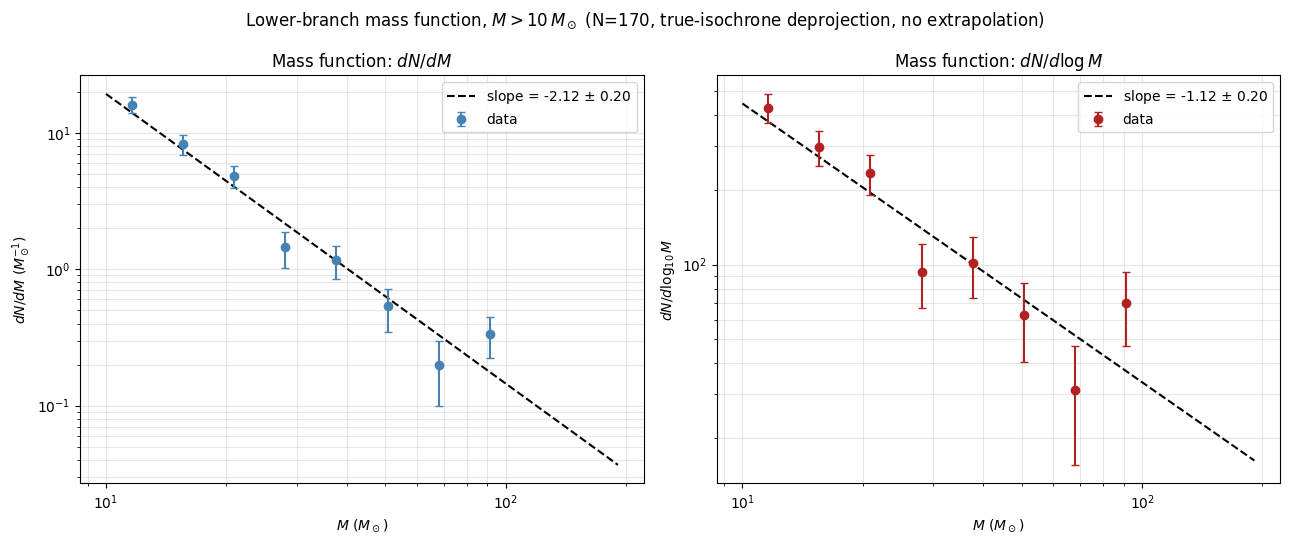

In [7]:
from scipy.stats import linregress


def fit_powerlaw_slope(x, y, yerr=None):
    """Unweighted least-squares power-law slope: log10(y) = slope*log10(x) + intercept.
    Returns (slope, slope_stderr, intercept)."""
    finite = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    result = linregress(np.log10(x[finite]), np.log10(y[finite]))
    return result.slope, result.stderr, result.intercept


mass_function_threshold = 10  # Msun

mf_mask = matched_lower & (mass_iso_lower > mass_function_threshold)
mf_mass = mass_iso_lower[mf_mask]
print(f'N sources with matched isochrone mass > {mass_function_threshold} Msun: {mf_mask.sum()}')

n_bins = 10
bin_edges = np.logspace(np.log10(mass_function_threshold), np.log10(mf_mass.max()), n_bins + 1)
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])  # geometric mean, appropriate for log bins
counts, _ = np.histogram(mf_mass, bins=bin_edges)
counts_err = np.sqrt(counts)

dM = np.diff(bin_edges)
dlogM = np.diff(np.log10(bin_edges))

dN_dM = counts / dM
dN_dM_err = counts_err / dM
dN_dlogM = counts / dlogM
dN_dlogM_err = counts_err / dlogM

nonzero = counts > 0
slope_dNdM, slope_dNdM_err, intercept_dNdM = fit_powerlaw_slope(bin_centers[nonzero], dN_dM[nonzero])
slope_dNdlogM, slope_dNdlogM_err, intercept_dNdlogM = fit_powerlaw_slope(bin_centers[nonzero], dN_dlogM[nonzero])

print(f'dN/dM  slope (alpha, dN/dM ~ M^slope):      {slope_dNdM:.2f} +/- {slope_dNdM_err:.2f}')
print(f'dN/dlogM slope (Gamma, dN/dlogM ~ M^slope): {slope_dNdlogM:.2f} +/- {slope_dNdlogM_err:.2f}')
print(f'(difference should be ~1: {slope_dNdlogM - slope_dNdM:.3f})')

mfit_x = np.array([bin_edges[0], bin_edges[-1]])

fig, (axM, axlogM) = plt.subplots(1, 2, figsize=(13, 5.5))

axM.errorbar(bin_centers[nonzero], dN_dM[nonzero], yerr=dN_dM_err[nonzero], fmt='o', color='steelblue',
             capsize=3, zorder=3, label='data')
axM.plot(mfit_x, 10**intercept_dNdM * mfit_x**slope_dNdM, 'k--',
         label=f'slope = {slope_dNdM:.2f} $\pm$ {slope_dNdM_err:.2f}')
axM.set_xscale('log')
axM.set_yscale('log')
axM.set_xlabel(r'$M$ ($M_\odot$)')
axM.set_ylabel(r'$dN/dM$ ($M_\odot^{-1}$)')
axM.set_title(r'Mass function: $dN/dM$')
axM.legend(fontsize=10)
axM.grid(alpha=0.3, which='both')

axlogM.errorbar(bin_centers[nonzero], dN_dlogM[nonzero], yerr=dN_dlogM_err[nonzero], fmt='o', color='firebrick',
                 capsize=3, zorder=3, label='data')
axlogM.plot(mfit_x, 10**intercept_dNdlogM * mfit_x**slope_dNdlogM, 'k--',
            label=f'slope = {slope_dNdlogM:.2f} $\pm$ {slope_dNdlogM_err:.2f}')
axlogM.set_xscale('log')
axlogM.set_yscale('log')
axlogM.set_xlabel(r'$M$ ($M_\odot$)')
axlogM.set_ylabel(r'$dN/d\log_{10}M$')
axlogM.set_title(r'Mass function: $dN/d\log M$')
axlogM.legend(fontsize=10)
axlogM.grid(alpha=0.3, which='both')

fig.suptitle(f'Lower-branch mass function, $M>{mass_function_threshold}\,M_\odot$ '
             f'(N={mf_mask.sum()}, true-isochrone deprojection, no extrapolation)')
plt.tight_layout()
plt.savefig('lower_branch_mass_function.png', bbox_inches='tight')
plt.show()


## Cumulative mass function: a binning-free slope estimate

$N(>M)$, the number of sources more massive than $M$, needs no bin choice at all -- every source contributes its own step. For a power-law $dN/dM \propto M^{-\alpha}$, $N(>M) \propto M^{1-\alpha} = M^{-\Gamma}$ (using $\Gamma=\alpha-1$, the $dN/d\log M$ index), so a single log-log fit to $N(>M)$ gives the power-law index in *both* representations at once: the fitted slope directly **is** the $dN/d\log M$ index $-\Gamma$, and the $dN/dM$ index is that slope minus 1.

cumulative N(>M) slope:                     -1.51 +/- 0.02
  -> implied dN/dlogM slope (Gamma):         -1.51 +/- 0.02
  -> implied dN/dM slope (alpha):            -2.51 +/- 0.02
(binned fits for comparison: dN/dM=-2.12+/-0.20, dN/dlogM=-1.12+/-0.20)


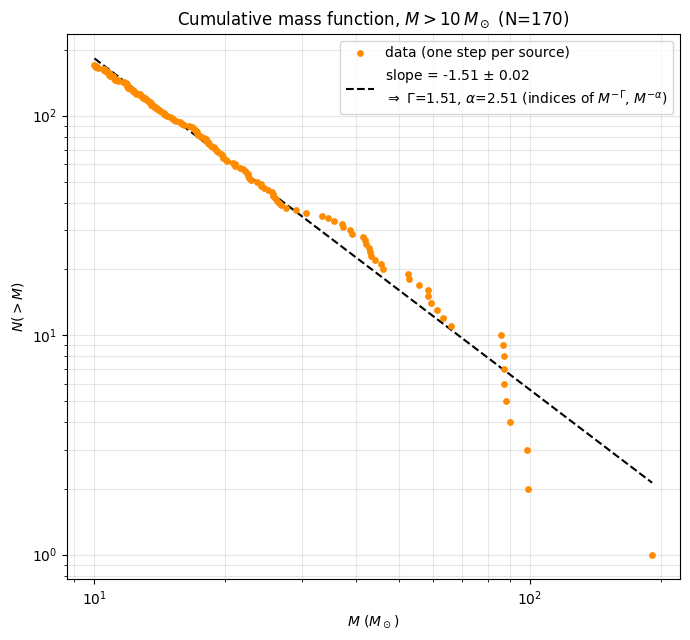

In [8]:
mass_sorted = np.sort(mf_mass)[::-1]  # descending
N_above = np.arange(1, len(mass_sorted) + 1)  # N(>=mass_sorted[i])

slope_cum, slope_cum_err, intercept_cum = fit_powerlaw_slope(mass_sorted, N_above)
slope_cum_dNdlogM = slope_cum        # N(>M) ~ M^slope_cum is the same power law as dN/dlogM
slope_cum_dNdM = slope_cum - 1       # dN/dM index is one less

print(f'cumulative N(>M) slope:                     {slope_cum:.2f} +/- {slope_cum_err:.2f}')
print(f'  -> implied dN/dlogM slope (Gamma):         {slope_cum_dNdlogM:.2f} +/- {slope_cum_err:.2f}')
print(f'  -> implied dN/dM slope (alpha):            {slope_cum_dNdM:.2f} +/- {slope_cum_err:.2f}')
print(f'(binned fits for comparison: dN/dM={slope_dNdM:.2f}+/-{slope_dNdM_err:.2f}, '
      f'dN/dlogM={slope_dNdlogM:.2f}+/-{slope_dNdlogM_err:.2f})')

fig, ax = plt.subplots(figsize=(7, 6.5))
ax.scatter(mass_sorted, N_above, s=15, color='darkorange', zorder=3, label='data (one step per source)')
cfit_x = np.array([mass_sorted.min(), mass_sorted.max()])
ax.plot(cfit_x, 10**intercept_cum * cfit_x**slope_cum, 'k--',
        label=(f'slope = {slope_cum:.2f} $\pm$ {slope_cum_err:.2f}\n'
               f'$\Rightarrow\ \Gamma$={-slope_cum_dNdlogM:.2f}, '
               f'$\\alpha$={-slope_cum_dNdM:.2f} (indices of $M^{{-\Gamma}}$, $M^{{-\\alpha}}$)'))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M$ ($M_\odot$)')
ax.set_ylabel(r'$N(>M)$')
ax.set_title(f'Cumulative mass function, $M>{mass_function_threshold}\,M_\odot$ (N={mf_mask.sum()})')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('lower_branch_mass_function_cumulative.png', bbox_inches='tight')
plt.show()


### Sanity check: the $M>10\,M_\odot$ selection on the CMD

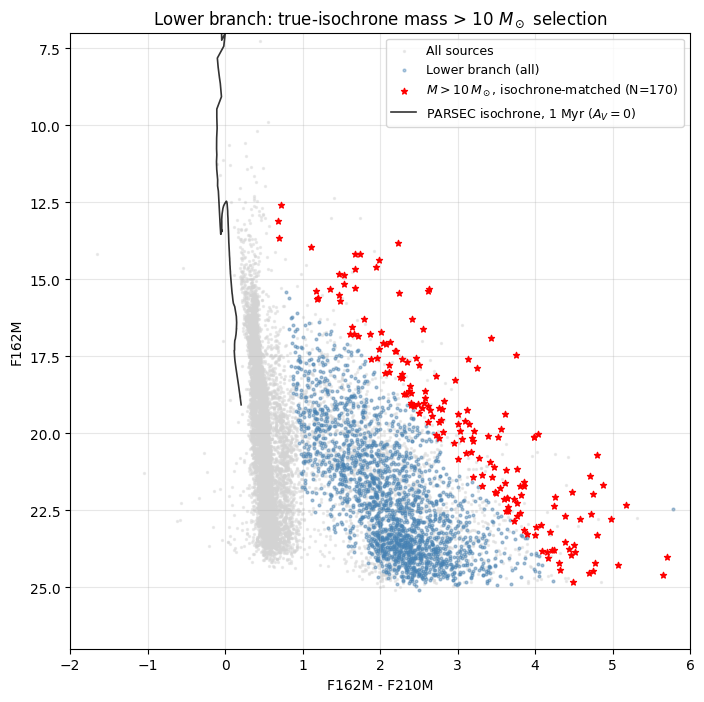

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(f162 - f210, f162, s=2, c='lightgray', alpha=0.4, label='All sources')
ax.scatter((f162 - f210)[lower_mask_all], f162[lower_mask_all], s=4, c='steelblue', alpha=0.4,
           label='Lower branch (all)')
lower_indices = np.where(lower_mask_all)[0]
mf_indices = lower_indices[mf_mask]
ax.scatter((f162 - f210)[mf_indices], f162[mf_indices], s=20, c='red', marker='*', zorder=4,
           label=f'$M>{mass_function_threshold}\,M_\odot$, isochrone-matched (N={mf_mask.sum()})')
ax.plot(color_track, mag_track, color='black', lw=1.2, alpha=0.8, label='PARSEC isochrone, 1 Myr ($A_V=0$)')
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F162M')
ax.set_ylim(27, 7)
ax.set_xlim(-2, 6)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
ax.set_title('Lower branch: true-isochrone mass > 10 $M_\odot$ selection')
plt.savefig('lower_branch_mass_function_cmd_check.png', bbox_inches='tight')
plt.show()


## The low-mass end of the lower branch: bare stars, or something else?

The lower branch is defined by *color*, not by local environment -- nothing so far has looked at whether a source actually sits in dense natal gas. Reusing the method from `color_magnitude_diagram_cleancat.ipynb` (`co_plank`, despite its name and filename, is confirmed there to be the ATLASGAL 870 $\mu$m continuum map reprojected onto the F480M grid, in Jy/beam; nearest-pixel lookup via `ix`/`iy`), we flag lower-branch sources sitting on **low 870 $\mu$m continuum** -- i.e. not currently embedded in a dense gas clump -- and show the CMD with those sources removed, to see whether they matter for the shape of the low-mass end.

N lower branch: 2260
N lower branch with 870um continuum < 1.5 Jy/beam (low-density environment): 811


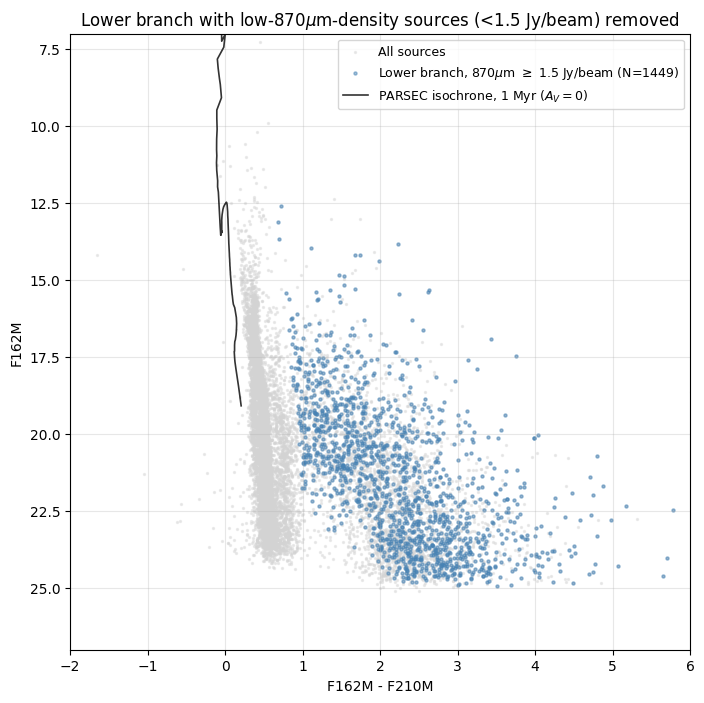

In [10]:
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization import simple_norm

wcs_f480m = WCS(headers['f480m'])
f480m_data = fits.getdata(image_filenames['f480m'], ext=('SCI', 1))
pixcoord_ref = wcs_f480m.all_world2pix(catalog['skycoord_ref'].ra.deg, catalog['skycoord_ref'].dec.deg, 0)

# despite the variable name, this is the ATLASGAL 870um continuum map (Jy/beam), reprojected
# onto the F480M pixel grid -- see the note in color_magnitude_diagram_cleancat.ipynb
co_planck_fn = '/orange/adamginsburg/jwst/w51/data_reprojected_480/co_planck_reprojected_to_f480m.fits'
co_plank = fits.getdata(co_planck_fn, ext=0)

ix = np.clip(np.round(pixcoord_ref[0]).astype(int), 0, co_plank.shape[1] - 1)
iy = np.clip(np.round(pixcoord_ref[1]).astype(int), 0, co_plank.shape[0] - 1)
co_plank_at_source = co_plank[iy, ix]

flux_870_threshold = 1.5  # Jy/beam -- try 1.0 for the stricter cut used in the reference notebook
low_870_mask_lower = (co_plank_at_source[lower_mask_all] < flux_870_threshold)
print(f'N lower branch: {lower_mask_all.sum()}')
print(f'N lower branch with 870um continuum < {flux_870_threshold} Jy/beam (low-density environment): '
      f'{low_870_mask_lower.sum()}')

color_lower_all = (f162 - f210)[lower_mask_all]
mag_lower_all = f162[lower_mask_all]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(f162 - f210, f162, s=2, c='lightgray', alpha=0.4, label='All sources')
ax.scatter(color_lower_all[~low_870_mask_lower], mag_lower_all[~low_870_mask_lower], s=5, c='steelblue',
           alpha=0.5, label=f'Lower branch, 870$\mu$m $\geq$ {flux_870_threshold} Jy/beam '
                             f'(N={(~low_870_mask_lower).sum()})')
ax.plot(color_track, mag_track, color='black', lw=1.2, alpha=0.8, label='PARSEC isochrone, 1 Myr ($A_V=0$)')
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F162M')
ax.set_ylim(27, 7)
ax.set_xlim(-2, 6)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
ax.set_title(f'Lower branch with low-870$\mu$m-density sources (<{flux_870_threshold} Jy/beam) removed')
plt.savefig('lower_branch_cmd_no_low_870um.png', bbox_inches='tight')
plt.show()


## CMD color-coded by isochrone mass, with the isochrone's degenerate "hook" masked out

The 1 Myr PARSEC track is not monotonic in the direction perpendicular to reddening (the coordinate that actually determines the dereddened match): it briefly folds back on itself around a few $M_\odot$ (the well-known PMS "hook" near the radiative-convective transition). Detected directly from the tabulated track below (a sign change in $t=\mathrm{color}\cdot\Delta m_{A_V} - \mathrm{mag}\cdot\Delta c_{A_V}$, the reddening-invariant coordinate, restricted to a plausible hook mass window so sparse-grid noise elsewhere isn't mistaken for a fold) -- inside that range a single dereddened position can correspond to more than one true mass.

The degenerate sources have to be identified by each source's own $t$ value falling in the range the hook spans, not by the mass `deproject_isochrone_mass` happened to assign: its least-reddened tie-break systematically routes degenerate sources onto the non-hook part of the track (checked directly: masking on assigned mass alone catches 0 sources, vs. well over a hundred using $t$).

Isochrone hook (non-monotonic in the dereddened coordinate): 4.08 - 5.14 Msun
N lower branch matched to the isochrone: 2199
N in the degenerate hook range (left uncolored): 160
N safely color-coded by mass: 2039


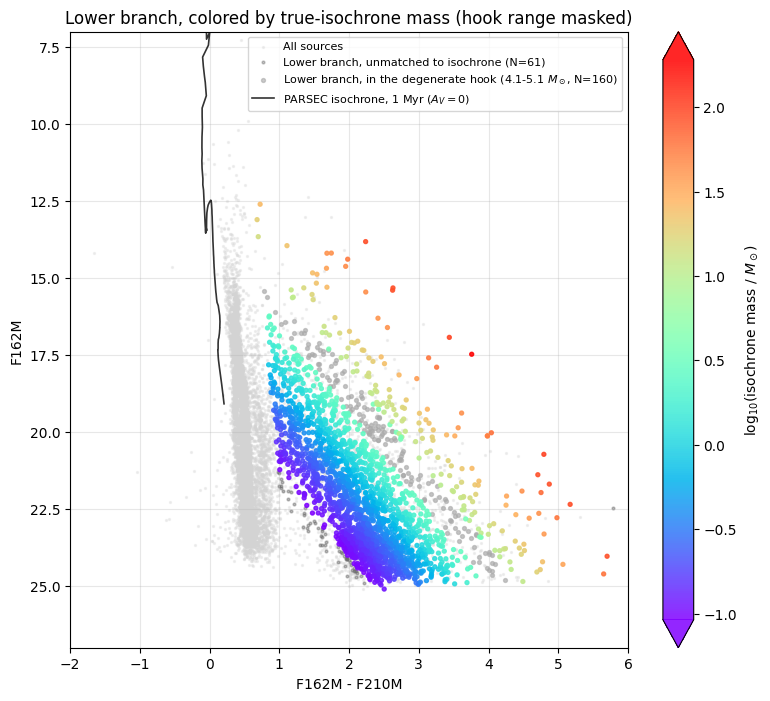

In [11]:
t_track = color_track * dmag_per_av - mag_track * dcolor_per_av

# restrict the search to a plausible PMS-hook mass window, so unrelated sparse-grid steps
# at the very low- or very high-mass ends of the track aren't mistaken for a real fold
hook_search = (mass_track > 2) & (mass_track < 15)
dt = np.diff(t_track)
dt_search = hook_search[:-1] & hook_search[1:]
significant = (np.abs(dt) > 0.001) & dt_search
sign = np.where(significant, np.sign(dt), 0)
nz_mask = sign != 0
turn_idx = np.where(nz_mask)[0][1:][np.diff(sign[nz_mask]) != 0]

hook_mass_min, hook_mass_max = mass_track[turn_idx].min(), mass_track[turn_idx].max()
in_hook_mass = (mass_track >= hook_mass_min) & (mass_track <= hook_mass_max)
t_hook_min, t_hook_max = t_track[in_hook_mass].min(), t_track[in_hook_mass].max()
print(f'Isochrone hook (non-monotonic in the dereddened coordinate): '
      f'{hook_mass_min:.2f} - {hook_mass_max:.2f} Msun')

# mask by each source's OWN (reddening-invariant) t coordinate falling in the hook's t-range,
# not by the mass the deprojection happened to assign: the least-reddened tie-break in
# deproject_isochrone_mass systematically routes degenerate sources onto the non-hook part of
# the track, so masking on the assigned mass alone misses essentially all of them (checked:
# 0 sources land in the hook mass range this way, vs the count below using t directly)
t_obs_lower = color_lower_all * dmag_per_av - mag_lower_all * dcolor_per_av
in_hook = matched_lower & (t_obs_lower >= t_hook_min) & (t_obs_lower <= t_hook_max)
colorable = matched_lower & ~in_hook
print(f'N lower branch matched to the isochrone: {matched_lower.sum()}')
print(f'N in the degenerate hook range (left uncolored): {in_hook.sum()}')
print(f'N safely color-coded by mass: {colorable.sum()}')

fig, ax = plt.subplots(figsize=(9, 8))
ax.scatter(f162 - f210, f162, s=2, c='lightgray', alpha=0.3, label='All sources')
ax.scatter(color_lower_all[~matched_lower], mag_lower_all[~matched_lower], s=4, c='dimgray', alpha=0.4,
           label=f'Lower branch, unmatched to isochrone (N={(~matched_lower).sum()})')
ax.scatter(color_lower_all[in_hook], mag_lower_all[in_hook], s=8, c='darkgray', alpha=0.6,
           label=f'Lower branch, in the degenerate hook ({hook_mass_min:.1f}-{hook_mass_max:.1f} '
                 f'$M_\odot$, N={in_hook.sum()})')
im = ax.scatter(color_lower_all[colorable], mag_lower_all[colorable], s=8,
                 c=np.log10(mass_iso_lower[colorable]), cmap='rainbow', alpha=0.85, zorder=4)
ax.plot(color_track, mag_track, color='black', lw=1.2, alpha=0.8, label='PARSEC isochrone, 1 Myr ($A_V=0$)')
cbar = plt.colorbar(im, ax=ax, extend='both')
cbar.set_label(r'log$_{10}$(isochrone mass / $M_\odot$)')
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F162M')
ax.set_ylim(27, 7)
ax.set_xlim(-2, 6)
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.3)
ax.set_title('Lower branch, colored by true-isochrone mass (hook range masked)')
plt.savefig('lower_branch_cmd_colored_by_mass_hook_masked.png', bbox_inches='tight')
plt.show()


## What are the low-mass, low-870$\mu$m-density lower-branch sources?

Removing the sources with little 870 $\mu$m continuum at their position (above) barely touches the shape of the low-mass end of the lower branch, so this population isn't just an artifact of dense-clump-projected photometry: most low-mass lower-branch sources already sit where there isn't much dense gas *in projection*. A few points worth separating, since "low 870 $\mu$m flux at the source position" and "no circumstellar dust" are not the same claim:

- **A_V here is a line-of-sight quantity, not a local-environment one.** The branch definition requires $A_V>12$ from `get_av`, which reddens the source itself; the 870 $\mu$m flux measures dense gas *projected at that sky position*, which need not be physically associated with the star (foreground/background diffuse ISM along the sightline reddens just as well as a natal envelope does). A source can be genuinely embedded in a natal core with A_V well above 12 *and* still sit in a 870 $\mu$m-faint pixel, if the emitting dust is warm/compact and the single-dish 870 $\mu$m beam (21$''$, coarse next to NIRCam's resolution) simply doesn't resolve or centroid on it -- so this cut is at best a coarse, projected proxy for "not in a dense clump," not proof of "dust-free."
- **This NIR/MIR color selection is only sensitive to warm inner-disk dust.** F360M/F480M excess (what separates the branches to begin with) traces hot dust close to the star. A star that has cleared its *inner* disk (a transition disk) while retaining a cooler outer disk, or one whose disk is simply faint relative to this survey's depth, would show no excess here without being genuinely diskless.
- **Malmquist-type bias favors exactly this appearance.** At $\lesssim1$ Myr, low-mass PMS stars are intrinsically faint and still contracting; a deeply embedded, dusty low-mass source is preferentially *not* detected (or scattered into the upper branch / missing-NIR "very red" category) rather than appearing here as a clean, low-extinction point. The detected low-mass lower-branch population is thus the least-embedded tail of the true low-mass population by construction, not a random sample of it.
- **Line-of-sight contamination is a real alternative.** A $A_V>12$, no-excess source could simply be a reddened field star (foreground disk population, or something well behind W51) with nothing to do with the protocluster's current star formation -- reddened by diffuse foreground ISM rather than a natal envelope, which would trivially explain the absence of any disk signature.

On the specific expectation -- yes, disk fractions in young ($\lesssim1$-2 Myr) clusters are typically still high (order 50-80% in well-studied nearby regions), so *most* genuine low-mass members this young should show some IR excess. But that fraction is not 100% even at these ages (fast disk dissipation, dynamical truncation in a crowded cluster, or photoevaporation near the OB stars powering W51 can all clear inner disks early), and every effect above works in the direction of making already-diskless-*looking* sources over-represented in this particular selection. So the honest read is that this subsample is probably a mix -- some genuinely early diskless/transition-disk objects, plus a real contribution from line-of-sight contaminants and survey-depth/geometry bias -- rather than being cleanly explained by any one of these on its own.

## Spatial distribution of the $M>10\,M_\odot$ lower-branch sources, and left vs. right half of the field

The $M>10\,M_\odot$ isochrone-matched lower-branch sources (the same sample as the mass function above) plotted on the F480M image, in the image's own pixel frame (the mosaic is rotated relative to north-up, so "left"/"right" here means the image's $x$ axis, not east/west). The field is split at the midpoint of the image's $x$ axis, and the cumulative isochrone-mass distribution is compared between the two halves, both as absolute counts $N(>M)$ (with the same log-log slope fit as above) and as a normalized distribution with a two-sample Kolmogorov-Smirnov test.

image x midpoint: 2822.5 px
N(M>10 Msun) left half: 93, right half: 77
median mass  left: 16.9 Msun, right: 17.5 Msun


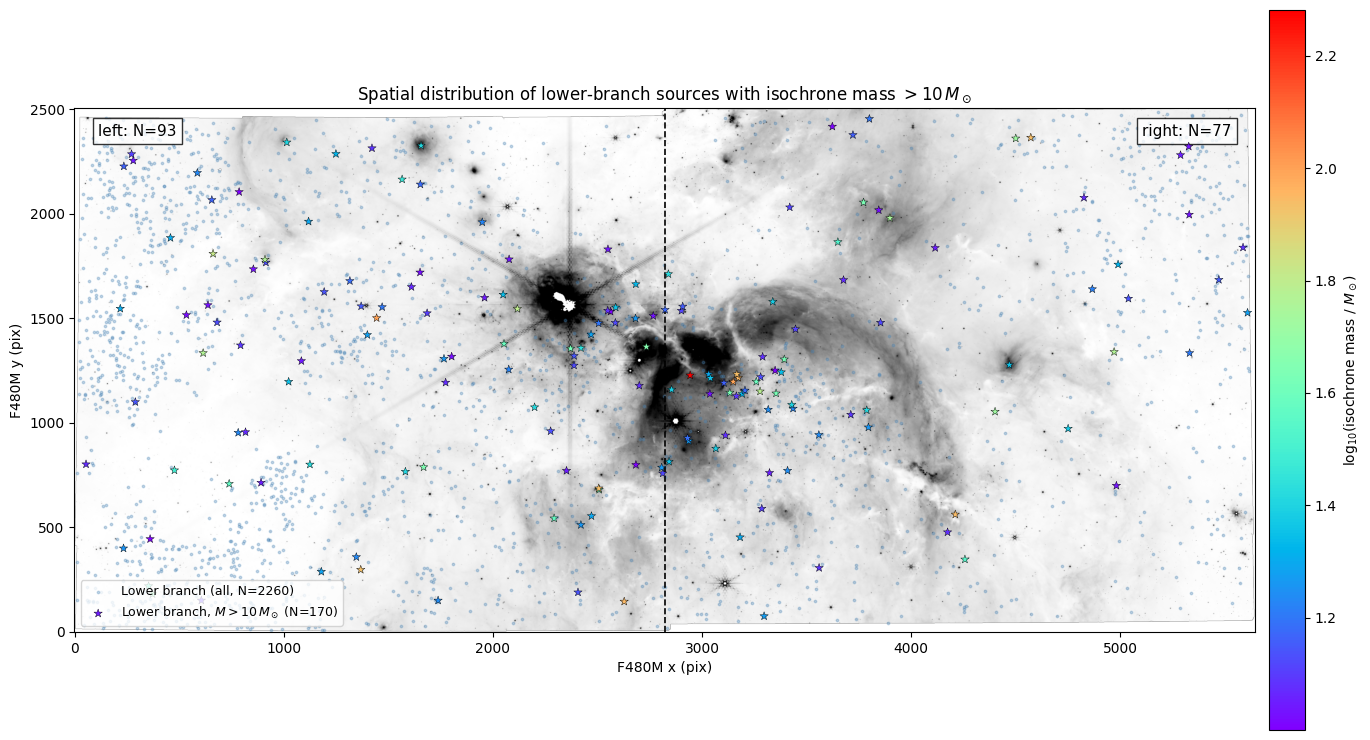

two-sample KS test: D = 0.092, p = 0.826
left  half: N=93, cumulative N(>M) slope = -1.57 +/- 0.02
right half: N=77, cumulative N(>M) slope = -1.37 +/- 0.02


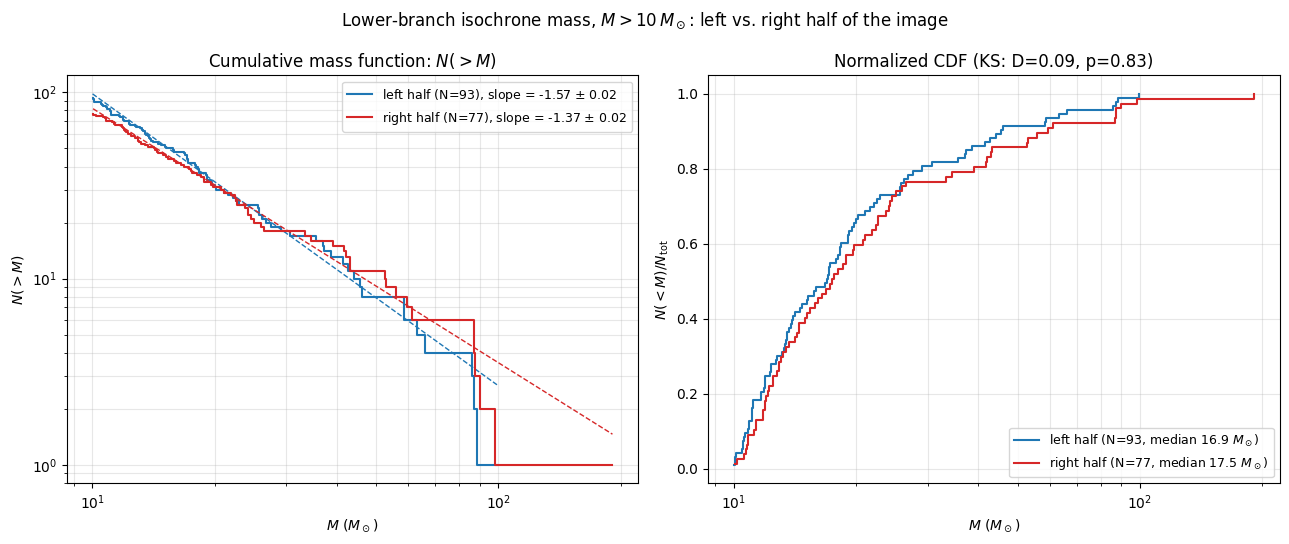

In [12]:
from scipy.stats import ks_2samp

x_mid = f480m_data.shape[1] / 2  # midpoint of the image x axis (F480M pixel frame)

px_lower = pixcoord_ref[0][lower_mask_all]
py_lower = pixcoord_ref[1][lower_mask_all]
px_mf, py_mf = px_lower[mf_mask], py_lower[mf_mask]
left_mf = px_mf < x_mid
right_mf = ~left_mf
mass_left = mf_mass[left_mf]
mass_right = mf_mass[right_mf]
print(f'image x midpoint: {x_mid:.1f} px')
print(f'N(M>{mass_function_threshold} Msun) left half: {left_mf.sum()}, right half: {right_mf.sum()}')
print(f'median mass  left: {np.median(mass_left):.1f} Msun, right: {np.median(mass_right):.1f} Msun')

# --- spatial map ---
fig, ax = plt.subplots(figsize=(15, 7.5))
norm_img = simple_norm(f480m_data, 'asinh', min_percent=1, max_percent=99.5)
ax.imshow(f480m_data, origin='lower', cmap='gray_r', norm=norm_img)
ax.scatter(px_lower, py_lower, s=3, c='steelblue', alpha=0.3,
           label=f'Lower branch (all, N={lower_mask_all.sum()})')
im = ax.scatter(px_mf, py_mf, s=40, c=np.log10(mf_mass), cmap='rainbow', marker='*',
                edgecolor='k', linewidth=0.3, zorder=4,
                label=f'Lower branch, $M>{mass_function_threshold}\,M_\odot$ (N={mf_mask.sum()})')
ax.axvline(x_mid, color='k', ls='--', lw=1.2)
ax.text(0.02, 0.97, f'left: N={left_mf.sum()}', transform=ax.transAxes, va='top', fontsize=11,
        bbox=dict(facecolor='white', alpha=0.8))
ax.text(0.98, 0.97, f'right: N={right_mf.sum()}', transform=ax.transAxes, va='top', ha='right',
        fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
cbar = plt.colorbar(im, ax=ax, pad=0.01)
cbar.set_label(r'log$_{10}$(isochrone mass / $M_\odot$)')
ax.set_xlabel('F480M x (pix)')
ax.set_ylabel('F480M y (pix)')
ax.set_title(f'Spatial distribution of lower-branch sources with isochrone mass $>{mass_function_threshold}\,M_\odot$')
ax.legend(fontsize=9, loc='lower left')
plt.tight_layout()
plt.savefig('lower_branch_m10_spatial_map.png', bbox_inches='tight')
plt.show()

# --- cumulative distributions, left vs right ---
ks = ks_2samp(mass_left, mass_right)
print(f'two-sample KS test: D = {ks.statistic:.3f}, p = {ks.pvalue:.3g}')

fig, (axN, axF) = plt.subplots(1, 2, figsize=(13, 5.5))
for m_half, name, color in [(mass_left, 'left', 'tab:blue'), (mass_right, 'right', 'tab:red')]:
    m_desc = np.sort(m_half)[::-1]
    n_above = np.arange(1, len(m_desc) + 1)
    s_half, s_half_err, b_half = fit_powerlaw_slope(m_desc, n_above)
    print(f'{name:5s} half: N={len(m_desc)}, cumulative N(>M) slope = {s_half:.2f} +/- {s_half_err:.2f}')
    axN.step(m_desc, n_above, where='post', color=color, lw=1.5,
             label=f'{name} half (N={len(m_desc)}), slope = {s_half:.2f} $\pm$ {s_half_err:.2f}')
    xfit = np.array([m_desc.min(), m_desc.max()])
    axN.plot(xfit, 10**b_half * xfit**s_half, '--', color=color, lw=1)

    m_asc = np.sort(m_half)
    axF.step(m_asc, np.arange(1, len(m_asc) + 1) / len(m_asc), where='post', color=color, lw=1.5,
             label=f'{name} half (N={len(m_asc)}, median {np.median(m_asc):.1f} $M_\odot$)')

axN.set_xscale('log')
axN.set_yscale('log')
axN.set_xlabel(r'$M$ ($M_\odot$)')
axN.set_ylabel(r'$N(>M)$')
axN.set_title(r'Cumulative mass function: $N(>M)$')
axN.legend(fontsize=9)
axN.grid(alpha=0.3, which='both')

axF.set_xscale('log')
axF.set_xlabel(r'$M$ ($M_\odot$)')
axF.set_ylabel(r'$N(<M)/N_{\rm tot}$')
axF.set_title(f'Normalized CDF (KS: D={ks.statistic:.2f}, p={ks.pvalue:.2g})')
axF.legend(fontsize=9, loc='lower right')
axF.grid(alpha=0.3, which='both')

fig.suptitle(f'Lower-branch isochrone mass, $M>{mass_function_threshold}\,M_\odot$: left vs. right half of the image')
plt.tight_layout()
plt.savefig('lower_branch_m10_cumulative_left_right.png', bbox_inches='tight')
plt.show()

## Mass function for $M>10\,M_\odot$ with low-870 $\mu$m sources removed

Same sample as the mass function above (isochrone-matched lower branch, $M>10\,M_\odot$), but now dropping every source that sits on ATLASGAL/LABOCA 870 $\mu$m continuum below `flux_870_threshold` (1.5 Jy/beam, nearest-pixel lookup from the section above). Sources outside dense gas in projection are the ones most likely to be reddened field stars behind (or in front of) W51 rather than cluster members, so this cut is a coarse background-contamination filter.

Three slope estimates are given for the filtered sample: the binned $dN/dM$ fit, the least-squares fit to $N(>M)$ (as above), and the maximum-likelihood estimator for a power law above $M_{\rm min}=10\,M_\odot$, $\hat\alpha = 1 + N\,/\sum_i \ln(M_i/M_{\rm min})$ with $\sigma_\alpha=(\hat\alpha-1)/\sqrt{N}$. The least-squares fit to $N(>M)$ uses correlated points, so its formal error is too small; the MLE is unbiased for a pure power law and gives a realistic uncertainty.

N(M>10 Msun), all lower branch: 170
N(M>10 Msun), 870um >= 1.5 Jy/beam: 154 (removed 16)

IMF index alpha (dN/dM ~ M^-alpha), 870um-filtered sample:
  binned dN/dM      : alpha = 2.07 +/- 0.20   (Gamma = alpha - 1 = 1.07)
  cumulative N(>M)  : alpha = 2.48 +/- 0.02   (Gamma = alpha - 1 = 1.48)
  max. likelihood   : alpha = 2.38 +/- 0.11   (Gamma = alpha - 1 = 1.38)
  (unfiltered for comparison: binned 2.12 +/- 0.20, cumulative 2.51 +/- 0.02, MLE 2.44)


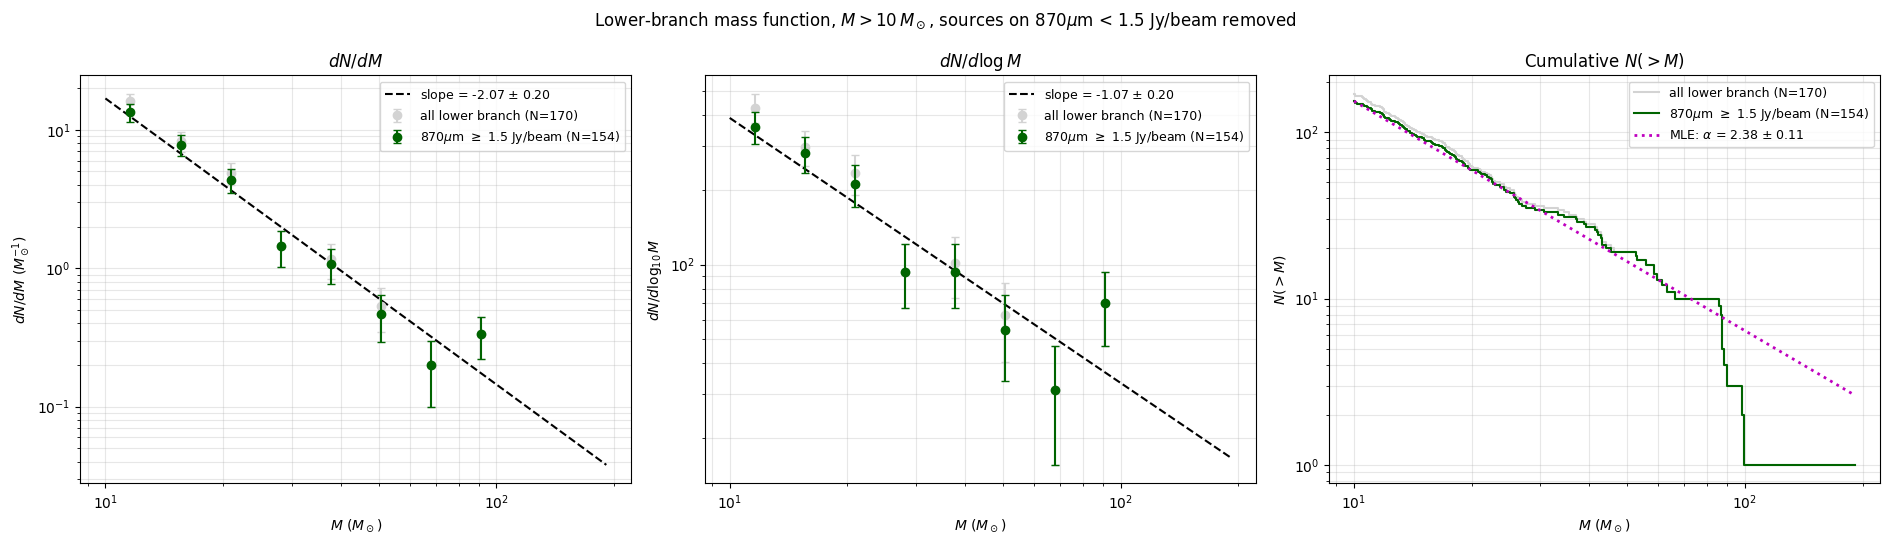

In [28]:
high870_lower = co_plank_at_source[lower_mask_all] >= flux_870_threshold
mf870_mask = mf_mask & high870_lower
mf870_mass = mass_iso_lower[mf870_mask]
n870 = mf870_mask.sum()
print(f'N(M>{mass_function_threshold} Msun), all lower branch: {mf_mask.sum()}')
print(f'N(M>{mass_function_threshold} Msun), 870um >= {flux_870_threshold} Jy/beam: {n870} '
      f'(removed {mf_mask.sum() - n870})')

# binned, same log-spaced bins as the unfiltered mass function
counts870, _ = np.histogram(mf870_mass, bins=bin_edges)
counts870_err = np.sqrt(counts870)
dN_dM_870, dN_dM_870_err = counts870 / dM, counts870_err / dM
dN_dlogM_870, dN_dlogM_870_err = counts870 / dlogM, counts870_err / dlogM
nz870 = counts870 > 0
slope870_dNdM, slope870_dNdM_err, int870_dNdM = fit_powerlaw_slope(bin_centers[nz870], dN_dM_870[nz870])
slope870_dNdlogM, slope870_dNdlogM_err, int870_dNdlogM = fit_powerlaw_slope(bin_centers[nz870], dN_dlogM_870[nz870])

# cumulative
mass870_desc = np.sort(mf870_mass)[::-1]
N_above_870 = np.arange(1, n870 + 1)
slope870_cum, slope870_cum_err, int870_cum = fit_powerlaw_slope(mass870_desc, N_above_870)

# maximum likelihood (continuous power law above M_min, Clauset et al. 2009)
alpha870_mle = 1 + n870 / np.sum(np.log(mf870_mass / mass_function_threshold))
alpha870_mle_err = (alpha870_mle - 1) / np.sqrt(n870)

alpha870 = {
    'binned dN/dM': (-slope870_dNdM, slope870_dNdM_err),
    'cumulative N(>M)': (1 - slope870_cum, slope870_cum_err),
    'max. likelihood': (alpha870_mle, alpha870_mle_err),
}
print('\nIMF index alpha (dN/dM ~ M^-alpha), 870um-filtered sample:')
for k, (a, ae) in alpha870.items():
    print(f'  {k:18s}: alpha = {a:.2f} +/- {ae:.2f}   (Gamma = alpha - 1 = {a - 1:.2f})')
print(f'  (unfiltered for comparison: binned {-slope_dNdM:.2f} +/- {slope_dNdM_err:.2f}, '
      f'cumulative {1 - slope_cum:.2f} +/- {slope_cum_err:.2f}, '
      f'MLE {1 + len(mf_mass) / np.sum(np.log(mf_mass / mass_function_threshold)):.2f})')

fig, (axM, axlogM, axC) = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, y_all, yerr_all, y870, yerr870, slope, slope_err, icpt, ylab in [
        (axM, dN_dM, dN_dM_err, dN_dM_870, dN_dM_870_err, slope870_dNdM, slope870_dNdM_err, int870_dNdM,
         r'$dN/dM$ ($M_\odot^{-1}$)'),
        (axlogM, dN_dlogM, dN_dlogM_err, dN_dlogM_870, dN_dlogM_870_err, slope870_dNdlogM, slope870_dNdlogM_err,
         int870_dNdlogM, r'$dN/d\log_{10}M$')]:
    ax.errorbar(bin_centers[nonzero], y_all[nonzero], yerr=yerr_all[nonzero], fmt='o', color='lightgray',
                capsize=3, label=f'all lower branch (N={mf_mask.sum()})')
    ax.errorbar(bin_centers[nz870], y870[nz870], yerr=yerr870[nz870], fmt='o', color='darkgreen', capsize=3,
                zorder=3, label=f'870$\mu$m $\geq$ {flux_870_threshold} Jy/beam (N={n870})')
    ax.plot(mfit_x, 10**icpt * mfit_x**slope, 'k--', label=f'slope = {slope:.2f} $\pm$ {slope_err:.2f}')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$M$ ($M_\odot$)')
    ax.set_ylabel(ylab)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which='both')
axM.set_title(r'$dN/dM$')
axlogM.set_title(r'$dN/d\log M$')

axC.step(mass_sorted, N_above, where='post', color='lightgray', lw=1.5, label=f'all lower branch (N={mf_mask.sum()})')
axC.step(mass870_desc, N_above_870, where='post', color='darkgreen', lw=1.5,
         label=f'870$\mu$m $\geq$ {flux_870_threshold} Jy/beam (N={n870})')
cx = np.array([mass870_desc.min(), mass870_desc.max()])
#axC.plot(cx, 10**int870_cum * cx**slope870_cum, 'k--',
#         label=f'LSQ slope = {slope870_cum:.2f} $\pm$ {slope870_cum_err:.2f}')
axC.plot(cx, n870 * (cx / mass_function_threshold)**(1 - alpha870_mle), 'm:', lw=2,
         label=f'MLE: $\\alpha$ = {alpha870_mle:.2f} $\pm$ {alpha870_mle_err:.2f}')
axC.set_xscale('log')
axC.set_yscale('log')
axC.set_xlabel(r'$M$ ($M_\odot$)')
axC.set_ylabel(r'$N(>M)$')
axC.set_title(r'Cumulative $N(>M)$')
axC.legend(fontsize=9)
axC.grid(alpha=0.3, which='both')

fig.suptitle(f'Lower-branch mass function, $M>{mass_function_threshold}\,M_\odot$, '
             f'sources on 870$\mu$m < {flux_870_threshold} Jy/beam removed')
plt.tight_layout()
plt.savefig('lower_branch_mass_function_870um_filtered.png', bbox_inches='tight')
plt.show()

## Total stellar mass implied by the filtered $M>10\,M_\odot$ counts

Take the observed upper-IMF index at face value, attach a standard low-mass IMF with its usual turnover, normalize to the observed number of stars with $10<M<M_{\rm up}$, and integrate $\int m\,\xi(m)\,dm$ over the full mass range. Two standard low-mass forms:

- **Kroupa (2001)**: broken power law, $\alpha=0.3$ for $0.01$-$0.08\,M_\odot$, $\alpha=1.3$ for $0.08$-$0.5\,M_\odot$, then the observed $\alpha$ from $0.5\,M_\odot$ to $M_{\rm up}$.
- **Chabrier (2005)**: log-normal with $m_c=0.2\,M_\odot$, $\sigma=0.55$ below $1\,M_\odot$ (continuous at $1\,M_\odot$), then the observed $\alpha$ from $1\,M_\odot$ to $M_{\rm up}$; lower limit $0.01\,M_\odot$.

$M_{\rm up}=150\,M_\odot$. For reference, the canonical Salpeter/Kroupa $\alpha=2.35$ is also listed. The $\pm$ range on each total mass comes from re-evaluating at $\alpha\pm\sigma_\alpha$.

N(M>10 Msun, 870um-filtered) = 154, summed observed mass = 4063 Msun
IMF integration range 0.01-150.0 Msun

slope estimate              alpha |          Kroupa total [Msun] |      Chabrier05 total [Msun] | f(>10) K / C
binned dN/dM          2.07 +/- 0.20 |  1.26e+04 (9.66e+03-1.85e+04) |  1.19e+04 (9.49e+03-1.62e+04) | 0.34 / 0.36
cumulative N(>M)      2.48 +/- 0.02 |  3.05e+04 ( 2.9e+04-3.22e+04) |  2.44e+04 (2.34e+04-2.54e+04) | 0.12 / 0.14
max. likelihood       2.38 +/- 0.11 |   2.4e+04 (1.86e+04-3.17e+04) |  2.01e+04 (1.63e+04-2.51e+04) | 0.15 / 0.18
canonical (2.35)      2.35 +/- 0.00 |  2.23e+04 (2.23e+04-2.23e+04) |  1.89e+04 (1.89e+04-1.89e+04) | 0.17 / 0.20


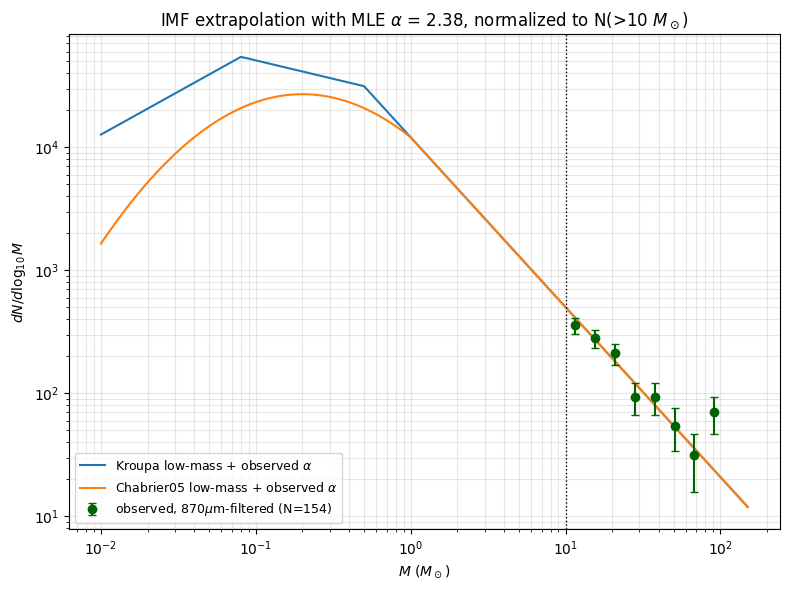

In [14]:
from scipy.integrate import quad

M_LOW_IMF, M_UP_IMF = 0.01, 150.0


def kroupa_shape(m, alpha_high):
    # continuous broken power law, breaks at 0.08 and 0.5 Msun
    a0, a1 = 0.3, 1.3
    k1 = 0.08**(a1 - a0)                  # continuity at 0.08
    k2 = k1 * 0.5**(alpha_high - a1)      # continuity at 0.5
    return np.where(m < 0.08, m**-a0, np.where(m < 0.5, k1 * m**-a1, k2 * m**-alpha_high))


def chabrier05_shape(m, alpha_high, mc=0.2, sigma=0.55):
    # dN/dm: log-normal below 1 Msun (dN/dlogm / (m ln10)), power law above, continuous at 1 Msun
    lognorm = lambda mm: np.exp(-(np.log10(mm) - np.log10(mc))**2 / (2 * sigma**2)) / (mm * np.log(10))
    return np.where(m < 1, lognorm(m), lognorm(1.0) * m**-alpha_high)


def total_mass_from_counts(shape, alpha_high, n_obs, m_min_obs=mass_function_threshold,
                           m_low=M_LOW_IMF, m_up=M_UP_IMF):
    breaks = [0.08, 0.5, 1.0, m_min_obs]
    n_shape = quad(lambda m: shape(m, alpha_high), m_min_obs, m_up)[0]
    m_shape = quad(lambda m: m * shape(m, alpha_high), m_low, m_up, points=breaks, limit=200)[0]
    m_obs_range = quad(lambda m: m * shape(m, alpha_high), m_min_obs, m_up)[0]
    norm = n_obs / n_shape
    return norm * m_shape, m_obs_range / m_shape  # total mass, fraction of mass in 10-150 Msun


observed_mass_sum = mf870_mass.sum()
print(f'N(M>{mass_function_threshold} Msun, 870um-filtered) = {n870}, summed observed mass = {observed_mass_sum:.0f} Msun')
print(f'IMF integration range {M_LOW_IMF}-{M_UP_IMF} Msun\n')

slope_cases = dict(alpha870)
slope_cases['canonical (2.35)'] = (2.35, 0.0)
rows = []
print(f'{"slope estimate":20s} {"alpha":>12s} | {"Kroupa total [Msun]":>28s} | {"Chabrier05 total [Msun]":>28s} | f(>10) K / C')
for name, (a, ae) in slope_cases.items():
    out = []
    for shape in (kroupa_shape, chabrier05_shape):
        mt, frac = total_mass_from_counts(shape, a, n870)
        if ae > 0:
            mt_lo = total_mass_from_counts(shape, a - ae, n870)[0]
            mt_hi = total_mass_from_counts(shape, a + ae, n870)[0]
        else:
            mt_lo = mt_hi = mt
        out.append((mt, min(mt_lo, mt_hi), max(mt_lo, mt_hi), frac))
    rows.append((name, a, ae, out))
    (k, klo, khi, kf), (c, clo, chi, cf) = out
    print(f'{name:20s} {a:5.2f} +/- {ae:4.2f} | {k:9.3g} ({klo:8.3g}-{khi:8.3g}) | '
          f'{c:9.3g} ({clo:8.3g}-{chi:8.3g}) | {kf:.2f} / {cf:.2f}')

# visualize the adopted IMFs, normalized to the observed counts (MLE slope)
fig, ax = plt.subplots(figsize=(8, 6))
mgrid = np.logspace(np.log10(M_LOW_IMF), np.log10(M_UP_IMF), 500)
for shape, label, color in [(kroupa_shape, 'Kroupa low-mass + observed $\\alpha$', 'tab:blue'),
                            (chabrier05_shape, 'Chabrier05 low-mass + observed $\\alpha$', 'tab:orange')]:
    norm = n870 / quad(lambda m: shape(m, alpha870_mle), mass_function_threshold, M_UP_IMF)[0]
    ax.plot(mgrid, norm * shape(mgrid, alpha870_mle) * mgrid * np.log(10), color=color, label=label)
ax.errorbar(bin_centers[nz870], dN_dlogM_870[nz870], yerr=dN_dlogM_870_err[nz870], fmt='o', color='darkgreen',
            capsize=3, zorder=3, label=f'observed, 870$\mu$m-filtered (N={n870})')
ax.axvline(mass_function_threshold, color='k', ls=':', lw=1)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M$ ($M_\odot$)')
ax.set_ylabel(r'$dN/d\log_{10}M$')
ax.set_title(f'IMF extrapolation with MLE $\\alpha$ = {alpha870_mle:.2f}, normalized to N(>10 $M_\odot$)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('lower_branch_imf_extrapolation_870um_filtered.png', bbox_inches='tight')
plt.show()

### Result: total stellar mass of the (filtered) lower-branch population

The 870 $\mu$m cut removes 16 of the 170 $M>10\,M_\odot$ sources (154 kept, summed isochrone mass $\approx4.1\times10^3\,M_\odot$) and barely changes the slope (MLE $\alpha$: 2.44 $\to$ 2.38). Adopting the MLE slope, $\alpha=2.38\pm0.11$, which is consistent with Salpeter:

| low-mass IMF | $M_{\rm tot}$ ($0.01$-$150\,M_\odot$) | fraction of mass in $>10\,M_\odot$ |
|---|---|---|
| Kroupa (2001) | $\approx2.4\times10^4\,M_\odot$ ($1.9$-$3.2\times10^4$) | 15% |
| Chabrier (2005) | $\approx2.0\times10^4\,M_\odot$ ($1.6$-$2.5\times10^4$) | 18% |

The result depends mostly on the adopted slope: the flatter binned fit ($\alpha=2.07$) gives $\approx1.2\times10^4\,M_\odot$, and the steeper $N(>M)$ least-squares fit ($\alpha=2.48$) gives $2.4$-$3.1\times10^4\,M_\odot$. The choice of low-mass IMF form matters at the $\sim20\%$ level.

Caveats: this counts only the lower branch (no NIR/MIR excess, $A_V>12$), so stars on the upper branch, at $A_V<12$, or undetected behind the densest gas are not included, which makes this a lower limit on the total stellar mass of the region; it assumes the $M>10\,M_\odot$ sample is complete and uncontaminated after the 870 $\mu$m cut; and masses come from single-star 1 Myr PARSEC deprojection (unresolved binaries and age spread would shift individual masses).

## Gas surface density of the unmasked area and comparison with the Kennicutt-Schmidt relation

**Gas surface density.** Optically thin dust emission gives the total gas surface density per pixel as

$$\Sigma_{\rm gas} = \frac{S_\nu}{\Omega_{\rm beam}\,B_\nu(T_d)\,\kappa_\nu},$$

with $S_\nu$ in Jy/beam, $\kappa_{870}=0.0185\,{\rm cm^2\,g^{-1}}$ (per gram of gas, gas-to-dust ratio 100; as used for ATLASGAL), and a 21$''$ FWHM beam (ATLASGAL+Planck combined map, Csengeri et al. 2016). $T_d=20$ K is the fiducial dust temperature, with 15-30 K as the range. The average is taken over all pixels inside the NIRCam footprint with $S_{870}\geq$ `flux_870_threshold`, i.e. the same area the $M>10\,M_\odot$ sources were kept in.

**SFR surface density.** $\mathrm{SFR}=M_{\rm tot}/1\,{\rm Myr}$ using the IMF-extrapolated total mass above (MLE slope; the central value is the mean of the Kroupa and Chabrier results, and the range spans both forms and $\alpha\pm\sigma_\alpha$), divided by the same unmasked area.

**Reference relations.**
- Kennicutt (1998): $\Sigma_{\rm SFR}=2.5\times10^{-4}\,(\Sigma_{\rm gas}/M_\odot\,{\rm pc^{-2}})^{1.4}\ M_\odot\,{\rm yr^{-1}\,kpc^{-2}}$ (disk-averaged, HI+H$_2$).
- Bigiel et al. (2008, 2010): $\Sigma_{\rm SFR}=10^{-2.1}\,(\Sigma_{\rm H_2}/10\,M_\odot\,{\rm pc^{-2}})^{1.0}$, i.e. a molecular depletion time of $\approx1.3$ Gyr (750 pc resolution, fit over $\Sigma_{\rm H_2}\sim3$-$50\,M_\odot\,{\rm pc^{-2}}$; dotted where extrapolated).

Individual data are overplotted: the 61 normal disks and 36 IR-selected circumnuclear starbursts from Kennicutt (1998) Tables 1-2 (parsed from the arXiv source into `kennicutt98_tables.csv`; for starbursts $\Sigma_{\rm gas}=\Sigma_{\rm H_2}$ as in K98), and the Bigiel et al. (2010) THINGS sampling points from VizieR J/AJ/140/1194 (cached as `bigiel10_*_disk_points.ecsv`): inner disks ($r<r_{25}$) with $\Sigma_{\rm gas}=\Sigma_{\rm HI}+\Sigma_{\rm H_2}$ ($\Sigma_{\rm H_2}=0$ where CO is undetected), and outer disks ($r>r_{25}$) with $\Sigma_{\rm gas}=\Sigma_{\rm HI}$. Bigiel points without an SFR uncertainty are upper limits (non-detections; shown in light gray). The compilations use different conventions: the VizieR Bigiel data include a factor 1.36 for helium and use Kroupa (inner disks, 750 pc sampling) or Chabrier (outer disks, 15$''$ sampling) SFR calibrations, while K98 uses a Salpeter (0.1-100 $M_\odot$) calibration. These shift points by $\lesssim0.2$ dex, small next to the offset of W51.

unmasked area: 86.9% of the NIRCam footprint = 32.4 pc2 = 3.24e-05 kpc2
870um in unmasked area: mean 7.64, median 4.04 Jy/beam

T_d = 20.0 K: 1.5 Jy/beam threshold -> Sigma_gas = 705 solMass / pc2
mean Sigma_gas (unmasked area) = 3588 solMass / pc2  (T_d 30-15 K: 2052-5612); median 1900 solMass / pc2
gas mass in unmasked area = 1.16e+05 solMass

M_star = 2.20e+04 solMass (1.63e+04-3.17e+04), SFR = 0.022 solMass / yr (0.016-0.032)
Sigma_SFR = 679 solMass / (yr kpc2) (504-978)
star formation efficiency M*/(M*+Mgas) = 0.16
gas depletion time Mgas/SFR = 5 Myr

at Sigma_gas = 3588 Msun/pc^2:
  Kennicutt98 predicts 23.7 Msun/yr/kpc^2 -> observed / K98 = 29
  Bigiel08/10 predicts 2.85 Msun/yr/kpc^2 -> observed / Bigiel = 238
Kennicutt98: 61 normal disks, 36 starbursts; Bigiel10: 4478 inner-disk points (982 with CO), 36777 outer-disk points; SFR detections: 3810 inner, 15359 outer


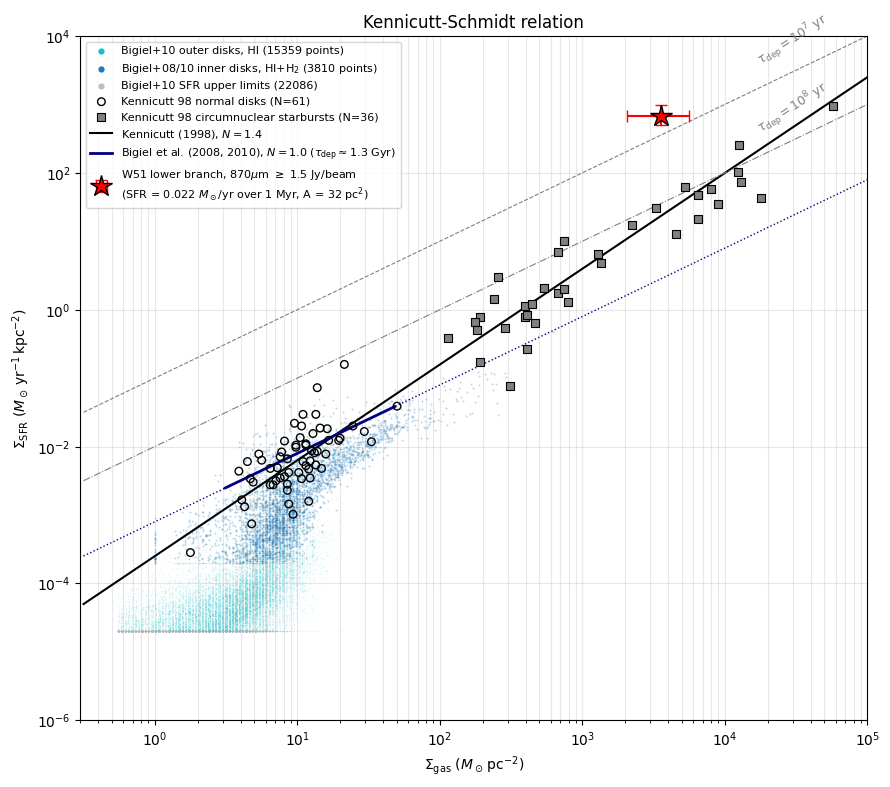

In [15]:
import astropy.constants as const
from astropy.modeling.models import BlackBody

kappa_870 = 0.0185 * u.cm**2 / u.g      # per gram of gas (gas-to-dust 100)
beam_fwhm_870 = 21 * u.arcsec           # ATLASGAL+Planck combined (Csengeri+16)
omega_beam_870 = (np.pi / (4 * np.log(2)) * beam_fwhm_870**2).to(u.sr)
nu_870 = (870 * u.um).to(u.GHz, equivalencies=u.spectral())
distance = 5.4 * u.kpc


def sigma_gas_from_870(s_jy_beam, t_dust):
    bnu = BlackBody(temperature=t_dust)(nu_870)  # per sr
    sigma = (s_jy_beam * u.Jy / (omega_beam_870 * bnu * kappa_870)).to(u.g / u.cm**2)
    return sigma.to(u.Msun / u.pc**2)


# unmasked area: inside the NIRCam footprint and on 870um >= threshold
footprint = np.isfinite(f480m_data) & (f480m_data != 0)
unmasked = footprint & (co_plank >= flux_870_threshold)
pix_area = (wcs_f480m.proj_plane_pixel_area()).to(u.arcsec**2)
area_unmasked = (unmasked.sum() * pix_area * (distance.to(u.pc) / u.rad)**2).to(u.pc**2, equivalencies=u.dimensionless_angles())
s870_mean = np.nanmean(co_plank[unmasked])
s870_median = np.nanmedian(co_plank[unmasked])
print(f'unmasked area: {unmasked.sum() / footprint.sum():.1%} of the NIRCam footprint = {area_unmasked:.1f} '
      f'= {area_unmasked.to(u.kpc**2):.2e}')
print(f'870um in unmasked area: mean {s870_mean:.2f}, median {s870_median:.2f} Jy/beam')

T_DUST_FID, T_DUST_RANGE = 20 * u.K, (15 * u.K, 30 * u.K)
sigma_gas_thresh = sigma_gas_from_870(flux_870_threshold, T_DUST_FID)
sigma_gas_mean = sigma_gas_from_870(s870_mean, T_DUST_FID)
sigma_gas_lo = sigma_gas_from_870(s870_mean, T_DUST_RANGE[1])
sigma_gas_hi = sigma_gas_from_870(s870_mean, T_DUST_RANGE[0])
print(f'\nT_d = {T_DUST_FID}: {flux_870_threshold} Jy/beam threshold -> Sigma_gas = {sigma_gas_thresh:.0f}')
print(f'mean Sigma_gas (unmasked area) = {sigma_gas_mean:.0f}  '
      f'(T_d 30-15 K: {sigma_gas_lo.value:.0f}-{sigma_gas_hi.value:.0f}); '
      f'median {sigma_gas_from_870(s870_median, T_DUST_FID):.0f}')
m_gas_unmasked = (sigma_gas_mean * area_unmasked).to(u.Msun)
print(f'gas mass in unmasked area = {m_gas_unmasked:.2e}')

# SFR from the IMF-extrapolated total mass (MLE slope row), 1 Myr
t_sf = 1 * u.Myr
mle_row = [r for r in rows if r[0] == 'max. likelihood'][0]
(mk, mk_lo, mk_hi, _), (mc, mc_lo, mc_hi, _) = mle_row[3]
mstar_tot = 0.5 * (mk + mc) * u.Msun
mstar_lo, mstar_hi = min(mk_lo, mc_lo) * u.Msun, max(mk_hi, mc_hi) * u.Msun
sfr = (mstar_tot / t_sf).to(u.Msun / u.yr)
sfr_lo, sfr_hi = (mstar_lo / t_sf).to(u.Msun / u.yr), (mstar_hi / t_sf).to(u.Msun / u.yr)
sigma_sfr = (sfr / area_unmasked).to(u.Msun / u.yr / u.kpc**2)
sigma_sfr_lo = (sfr_lo / area_unmasked).to(u.Msun / u.yr / u.kpc**2)
sigma_sfr_hi = (sfr_hi / area_unmasked).to(u.Msun / u.yr / u.kpc**2)
print(f'\nM_star = {mstar_tot:.2e} ({mstar_lo.value:.2e}-{mstar_hi.value:.2e}), SFR = {sfr:.3f} '
      f'({sfr_lo.value:.3f}-{sfr_hi.value:.3f})')
print(f'Sigma_SFR = {sigma_sfr:.0f} ({sigma_sfr_lo.value:.0f}-{sigma_sfr_hi.value:.0f})')
print(f'star formation efficiency M*/(M*+Mgas) = {(mstar_tot / (mstar_tot + m_gas_unmasked)).decompose():.2f}')
print(f'gas depletion time Mgas/SFR = {(m_gas_unmasked / sfr).to(u.Myr):.0f}')


def ks_kennicutt98(sigma_gas):
    return 2.5e-4 * sigma_gas**1.4


def ks_bigiel(sigma_gas):
    return 10**-2.1 * (sigma_gas / 10)**1.0


sg = sigma_gas_mean.value
ss = sigma_sfr.value
print(f'\nat Sigma_gas = {sg:.0f} Msun/pc^2:')
print(f'  Kennicutt98 predicts {ks_kennicutt98(sg):.1f} Msun/yr/kpc^2 -> observed / K98 = {ss / ks_kennicutt98(sg):.0f}')
print(f'  Bigiel08/10 predicts {ks_bigiel(sg):.2f} Msun/yr/kpc^2 -> observed / Bigiel = {ss / ks_bigiel(sg):.0f}')

# individual data points: Kennicutt (1998) Tables 1-2 (parsed from the arXiv source, see
# kennicutt98_tables.csv) and Bigiel et al. (2010) sampling points (VizieR J/AJ/140/1194, cached locally)
k98 = Table.read('kennicutt98_tables.csv', format='ascii.csv', comment='#')
k98_disk = k98['sample'] == 'normal disk'


def load_bigiel10(fn, vizier_table):
    if not os.path.exists(fn):
        from astroquery.vizier import Vizier
        Vizier.ROW_LIMIT = -1
        Vizier.get_catalogs('J/AJ/140/1194')[vizier_table].write(fn)
    return Table.read(fn)


b10_inner = load_bigiel10('bigiel10_inner_disk_points.ecsv', 'J/AJ/140/1194/table2')
b10_outer = load_bigiel10('bigiel10_outer_disk_points.ecsv', 'J/AJ/140/1194/table3')
# inner disks (r < r25): Sigma_gas = HI + H2, with H2 = 0 where CO is undetected
sig_h2_inner = np.where(np.ma.getmaskarray(b10_inner['logH2']), 0, 10**np.ma.filled(b10_inner['logH2'], 0))
b10_inner_gas = 10**np.asarray(b10_inner['logHI']) + sig_h2_inner
b10_inner_sfr = 10**np.asarray(b10_inner['logSFR'])
# outer disks (r > r25): HI only; SFR column is in units of 1e-5 Msun/yr/kpc^2
b10_outer_gas = 10**np.asarray(b10_outer['logHI'])
b10_outer_sfr = np.asarray(b10_outer['SFR']) * 1e-5
# rows without an SFR uncertainty are upper limits (non-detections at the FUV/SFR sensitivity; VizieR ReadMe)
b10_inner_det = ~np.ma.getmaskarray(b10_inner['e_logSFR'])
b10_outer_det = ~np.ma.getmaskarray(b10_outer['e_SFR'])
print(f'Kennicutt98: {k98_disk.sum()} normal disks, {(~k98_disk).sum()} starbursts; '
      f'Bigiel10: {len(b10_inner)} inner-disk points ({(~np.ma.getmaskarray(b10_inner["logH2"])).sum()} with CO), '
      f'{len(b10_outer)} outer-disk points; SFR detections: {b10_inner_det.sum()} inner, {b10_outer_det.sum()} outer')

fig, ax = plt.subplots(figsize=(9, 8))
xg = np.logspace(-0.5, 5, 200)
ax.scatter(np.r_[b10_outer_gas[~b10_outer_det], b10_inner_gas[~b10_inner_det]],
           np.r_[b10_outer_sfr[~b10_outer_det], b10_inner_sfr[~b10_inner_det]],
           s=1, color='0.75', alpha=0.1, rasterized=True, lw=0)
ax.scatter(b10_outer_gas[b10_outer_det], b10_outer_sfr[b10_outer_det], s=1, color='tab:cyan', alpha=0.1,
           rasterized=True, lw=0)
ax.scatter(b10_inner_gas[b10_inner_det], b10_inner_sfr[b10_inner_det], s=2, color='tab:blue', alpha=0.3,
           rasterized=True, lw=0)
ax.scatter([], [], s=12, color='tab:cyan', label=f'Bigiel+10 outer disks, HI ({b10_outer_det.sum()} points)')
ax.scatter([], [], s=12, color='tab:blue', label=f'Bigiel+08/10 inner disks, HI+H$_2$ ({b10_inner_det.sum()} points)')
ax.scatter([], [], s=12, color='0.75', label=f'Bigiel+10 SFR upper limits ({(~b10_outer_det).sum() + (~b10_inner_det).sum()})')
ax.scatter(10**k98['log_sigma_gas'][k98_disk], 10**k98['log_sigma_SFR'][k98_disk], s=30, facecolor='none',
           edgecolor='k', lw=1, zorder=4, label=f'Kennicutt 98 normal disks (N={k98_disk.sum()})')
ax.scatter(10**k98['log_sigma_gas'][~k98_disk], 10**k98['log_sigma_SFR'][~k98_disk], s=30, marker='s',
           facecolor='0.5', edgecolor='k', lw=0.8, zorder=4,
           label=f'Kennicutt 98 circumnuclear starbursts (N={(~k98_disk).sum()})')
ax.plot(xg, ks_kennicutt98(xg), 'k-', lw=1.5, label='Kennicutt (1998), $N=1.4$')
in_bigiel = (xg >= 3) & (xg <= 50)
ax.plot(xg[in_bigiel], ks_bigiel(xg[in_bigiel]), color='navy', lw=2,
        label=r'Bigiel et al. (2008, 2010), $N=1.0$ ($\tau_{\rm dep}\approx1.3$ Gyr)')
ax.plot(xg, ks_bigiel(xg), color='navy', lw=1, ls=':')
for tdep, ls in [(1e7, '--'), (1e8, '-.')]:
    ax.plot(xg, xg * 1e6 / tdep, color='gray', lw=0.8, ls=ls)
    ax.text(3e4, 3e4 * 1e6 / tdep * 1.3, f'$\\tau_{{\\rm dep}}=10^{{{int(np.log10(tdep))}}}$ yr', color='gray',
            fontsize=9, rotation=33, ha='center')
ax.errorbar(sg, ss, xerr=[[sg - sigma_gas_lo.value], [sigma_gas_hi.value - sg]],
            yerr=[[ss - sigma_sfr_lo.value], [sigma_sfr_hi.value - ss]],
            fmt='*', ms=16, color='red', mec='k', capsize=4, zorder=5,
            label=f'W51 lower branch, 870$\\mu$m $\\geq$ {flux_870_threshold} Jy/beam\n'
                  f'(SFR = {sfr.value:.3f} $M_\\odot$/yr over 1 Myr, A = {area_unmasked.value:.0f} pc$^2$)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.3, 1e5)
ax.set_ylim(1e-6, 1e4)
ax.set_xlabel(r'$\Sigma_{\rm gas}$ ($M_\odot\,{\rm pc^{-2}}$)')
ax.set_ylabel(r'$\Sigma_{\rm SFR}$ ($M_\odot\,{\rm yr^{-1}\,kpc^{-2}}$)')
ax.set_title('Kennicutt-Schmidt relation')
ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('lower_branch_kennicutt_schmidt.png', bbox_inches='tight')
plt.show()

### Result: W51 on the Kennicutt-Schmidt diagram

| quantity | value |
|---|---|
| 1.5 Jy/beam threshold ($T_d=20$ K) | $\Sigma_{\rm gas}\approx700\,M_\odot\,{\rm pc^{-2}}$ |
| unmasked area | 87% of the NIRCam footprint, 32 pc$^2$ |
| mean (median) 870 $\mu$m in that area | 7.6 (4.0) Jy/beam |
| mean $\Sigma_{\rm gas}$ | $\approx3.6\times10^3\,M_\odot\,{\rm pc^{-2}}$ (2.1-5.6$\times10^3$ for $T_d=30$-15 K); $M_{\rm gas}\approx1.2\times10^5\,M_\odot$ |
| SFR ($M_\star\approx2.2\times10^4\,M_\odot$ / 1 Myr) | $0.022\,M_\odot\,{\rm yr^{-1}}$ (0.016-0.032) |
| $\Sigma_{\rm SFR}$ | $\approx680\,M_\odot\,{\rm yr^{-1}\,kpc^{-2}}$ (500-980) |
| $M_\star/(M_\star+M_{\rm gas})$, $\tau_{\rm dep}=M_{\rm gas}/{\rm SFR}$ | 0.16, $\approx5$ Myr |

At the measured $\Sigma_{\rm gas}$, W51 lies $\approx30\times$ above Kennicutt (1998) and $\approx240\times$ above the Bigiel et al. (2008, 2010) molecular relation (which has to be extrapolated by ~2 dex in $\Sigma_{\rm gas}$ to reach this point). The implied depletion time ($\sim5$ Myr) is $\sim250\times$ shorter than the $\sim1.3$ Gyr typical of kpc-averaged molecular gas in nearby disks. This offset is in the same direction as found for Galactic star-forming clouds measured with YSO counts on pc scales (e.g. Heiderman et al. 2010; Lada et al. 2010; Evans et al. 2014): above a dense-gas threshold of order $10^2\,M_\odot\,{\rm pc^{-2}}$, regions form stars much faster than the extragalactic relations predict, because the kpc-scale relations average the dense, actively star-forming gas together with large amounts of diffuse, non-star-forming gas and with regions at different evolutionary stages.

Factors that move the point:
- **SF timescale.** $\Sigma_{\rm SFR}\propto1/t_{\rm SF}$; a 2-3 Myr timescale lowers it by $2$-$3\times$, which leaves W51 well above both relations.
- **SFR is a lower limit for the area.** Only lower-branch stars are counted; adding upper-branch (IR-excess) members and stars at $A_V<12$ or hidden behind the densest gas raises $\Sigma_{\rm SFR}$.
- **$\Sigma_{\rm gas}$ is likely an upper limit.** W51 dust near the HII regions is warmer than 20 K, and free-free emission contributes to the 870 $\mu$m flux toward W51 IRS2 / W51e, both of which make the true $\Sigma_{\rm gas}$ lower and move the point further above the relations.
- **Mean vs. median.** Using the median 870 $\mu$m flux (4.0 Jy/beam, $\Sigma_{\rm gas}\approx1.9\times10^3\,M_\odot\,{\rm pc^{-2}}$) instead of the mean moves the point left by 0.3 dex, increasing the offset further.

## W51 on the Gutermuth et al. (2011) gas-depletion model (their Fig. 13)

Gutermuth et al. (2011, ApJ 739, 84) found $\Sigma_\star\propto\Sigma_{\rm gas}^{\sim2}$ on $\sim$1 pc scales in eight nearby clouds and interpreted it with a simple gas-depletion model: a local star formation law $\partial\Sigma_{\rm gas}/\partial t=-k\,\Sigma_{\rm gas}^{\alpha}$ with no inflow, and a fraction $c$ of the depleted gas ending up in stars. For $\alpha=2$ the solution is

$$\Sigma_{\rm gas}(t)=\frac{\Sigma_0}{1+t/t_0},\qquad \Sigma_\star(t)=c\,\Sigma_0\,\frac{t/t_0}{1+t/t_0},\qquad t_0=\frac{1}{k\,\Sigma_0},$$

with their adopted $k=9.5\times10^{-4}\,{\rm Myr^{-1}\,pc^2\,}M_\odot^{-1}$ and $c=0.5$. As in their Fig. 13: gray lines are evolutionary tracks of parcels with fixed initial $\Sigma_0$ (20-2000 $M_\odot\,{\rm pc^{-2}}$ in the paper; extended here to $2\times10^4$, dotted, to reach W51), black lines are isochrones from 200 yr to 6.4 Myr, and the dot-dashed lines mark $t=t_0$ ($\Sigma_\star=c\,\Sigma_{\rm gas}$) and $t=0.1\,t_0$ ($\Sigma_\star=0.1\,c\,\Sigma_{\rm gas}$). The MonR2 (green) and Ophiuchus (blue) polygons are reconstructed from their Table 2 power-law fits ($\log\Sigma_\star=-4.42+2.67\log\Sigma_{\rm gas}$ and $-3.10+1.87\log\Sigma_{\rm gas}$) $\pm0.5$ dex over the observed $\Sigma_{\rm gas}$ ranges (15-295 and 15-540 $M_\odot\,{\rm pc^{-2}}$), matching the polygons in their Figs. 13 and 15.

W51 is placed at $\Sigma_\star=M_\star/A$ (IMF-extrapolated total stellar mass of the filtered lower branch over the unmasked area) and the mean $\Sigma_{\rm gas}$ from the 870 $\mu$m map. Note the different $\Sigma_\star$ definitions: Gutermuth et al. count Class I+II YSOs with a mean mass of 0.5 $M_\odot$ (disk-bearing members only), while here $\Sigma_\star$ is the IMF-integrated mass of the no-excess lower-branch population. The 21$''$ ATLASGAL beam is 0.55 pc at 5.4 kpc, comparable to the 0.2-0.95 pc resolution of their extinction maps, but the W51 point is a single average over 32 pc$^2$.

W51: Sigma_gas = 3588, Sigma_* = 679 (504-978) Msun/pc^2, Sigma_*/Sigma_gas = 0.19, Sigma_*/Sigma_gas^2 = 5.3e-05 pc^2/Msun
G11 model (alpha=2, k=0.00095, c=0.5): Sigma0 = 4947 Msun/pc^2, t/t0 = 0.38, model age = 81 kyr
  same Sigma0 after 1 Myr in the model: Sigma_gas = 868, Sigma_* = 2040 Msun/pc^2
  G11 alpha=2 law SFR density at the W51 Sigma_gas: 6115 Msun/yr/kpc^2 (observed 679; ratio observed/G11 = 0.11)


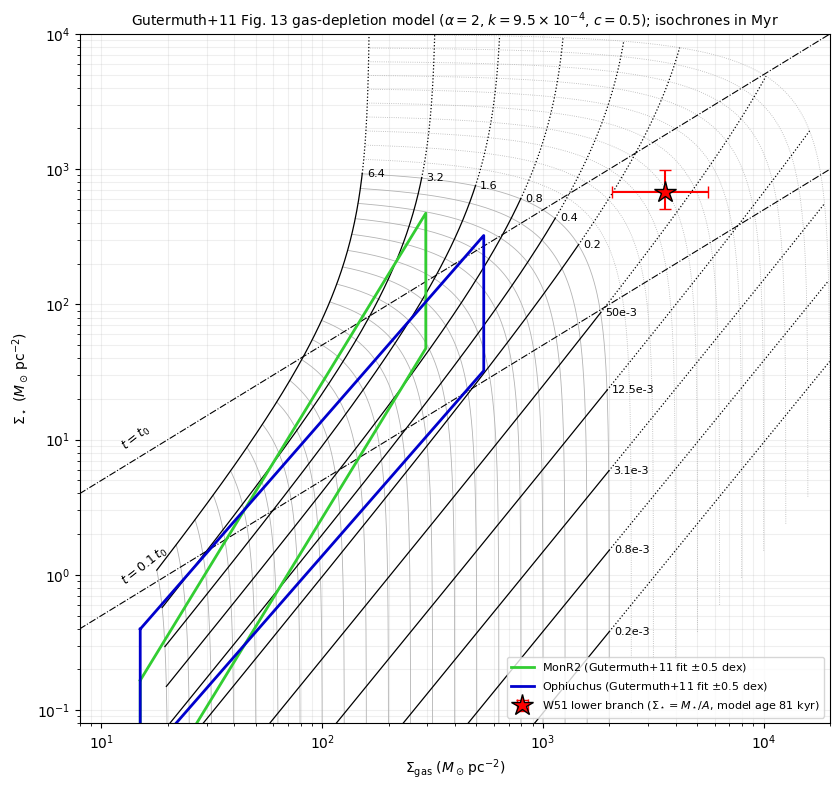

In [16]:
K_G11 = 9.5e-4      # Myr^-1 pc^2 Msun^-1 (alpha = 2)
C_G11 = 0.5


def g11_model(sigma0, t_myr, k=K_G11, c=C_G11):
    # alpha = 2 gas-depletion model of Gutermuth+11 (their eqs. for Sigma_gas(t), Sigma_*(t))
    x = k * sigma0 * t_myr          # = t / t0
    return sigma0 / (1 + x), c * sigma0 * x / (1 + x)


# W51 point
sig_star_w51 = (mstar_tot / area_unmasked).to_value(u.Msun / u.pc**2)
sig_star_w51_lo = (mstar_lo / area_unmasked).to_value(u.Msun / u.pc**2)
sig_star_w51_hi = (mstar_hi / area_unmasked).to_value(u.Msun / u.pc**2)
sg_w51 = sigma_gas_mean.to_value(u.Msun / u.pc**2)

# invert the model for the W51 point: Sigma0 = Sigma_gas + Sigma_*/c, t/t0 = Sigma_*/(c Sigma_gas)
sigma0_w51 = sg_w51 + sig_star_w51 / C_G11
x_w51 = sig_star_w51 / (C_G11 * sg_w51)
t_model_w51 = x_w51 / (K_G11 * sigma0_w51)
print(f'W51: Sigma_gas = {sg_w51:.0f}, Sigma_* = {sig_star_w51:.0f} ({sig_star_w51_lo:.0f}-{sig_star_w51_hi:.0f}) Msun/pc^2, '
      f'Sigma_*/Sigma_gas = {sig_star_w51 / sg_w51:.2f}, Sigma_*/Sigma_gas^2 = {sig_star_w51 / sg_w51**2:.1e} pc^2/Msun')
print(f'G11 model (alpha=2, k={K_G11}, c={C_G11}): Sigma0 = {sigma0_w51:.0f} Msun/pc^2, t/t0 = {x_w51:.2f}, '
      f'model age = {t_model_w51 * 1e3:.0f} kyr')
sg1, ss1 = g11_model(sigma0_w51, 1.0)
print(f'  same Sigma0 after 1 Myr in the model: Sigma_gas = {sg1:.0f}, Sigma_* = {ss1:.0f} Msun/pc^2')
sfr_g11 = C_G11 * K_G11 * sg_w51**2   # Msun/Myr/pc^2 == Msun/yr/kpc^2
print(f'  G11 alpha=2 law SFR density at the W51 Sigma_gas: {sfr_g11:.0f} Msun/yr/kpc^2 '
      f'(observed {sigma_sfr.value:.0f}; ratio observed/G11 = {sigma_sfr.value / sfr_g11:.2f})')

fig, ax = plt.subplots(figsize=(8.5, 8))
t_grid = np.logspace(-4.5, np.log10(6.4), 300)
for s0 in np.logspace(np.log10(20), np.log10(2e4), 31):
    sgt, sst = g11_model(s0, t_grid)
    ax.plot(sgt, sst, color='0.7', lw=0.6, ls='-' if s0 <= 2000 * 1.001 else ':')
iso_times = [0.2e-3, 0.8e-3, 3.1e-3, 12.5e-3, 50e-3, 0.2, 0.4, 0.8, 1.6, 3.2, 6.4]
s0_paper = np.logspace(np.log10(20), np.log10(2000), 200)
s0_ext = np.logspace(np.log10(2000), np.log10(2e4), 100)
for t_iso in iso_times:
    sgi, ssi = g11_model(s0_paper, t_iso)
    ax.plot(sgi, ssi, 'k-', lw=0.9)
    sge, sse = g11_model(s0_ext, t_iso)
    ax.plot(sge, sse, 'k:', lw=0.9)
    lab = f'{t_iso:g}' if t_iso >= 0.2 else f'{t_iso * 1e3:g}e-3'
    if ssi[-1] < 1500 and sgi[-1] < 7000:
        ax.text(sgi[-1] * 1.05, ssi[-1], lab, fontsize=8, va='center')
    elif sse[-1] < 1e4:
        ax.text(sge[-1] * 1.05, sse[-1], lab, fontsize=8, va='center')
xx = np.logspace(0.5, 5, 50)
ax.plot(xx, C_G11 * xx, 'k-.', lw=0.8)
ax.plot(xx, 0.1 * C_G11 * xx, 'k-.', lw=0.8)
ax.text(12, C_G11 * 12 * 1.4, '$t=t_0$', rotation=38, fontsize=9)
ax.text(12, 0.1 * C_G11 * 12 * 1.4, '$t=0.1\\,t_0$', rotation=38, fontsize=9)

for (a0, a1, xmin, xmax, color, name) in [(-4.42, 2.67, 15, 295, 'limegreen', 'MonR2'),
                                           (-3.10, 1.87, 15, 540, 'mediumblue', 'Ophiuchus')]:
    lx = np.log10([xmin, xmax])
    poly_x = 10**np.r_[lx, lx[::-1], lx[0]]
    poly_y = 10**(np.r_[a0 + a1 * lx + 0.5, (a0 + a1 * lx - 0.5)[::-1], a0 + a1 * lx[0] + 0.5])
    ax.plot(poly_x, poly_y, color=color, lw=2, label=f'{name} (Gutermuth+11 fit $\\pm$0.5 dex)')

ax.errorbar(sg_w51, sig_star_w51,
            xerr=[[sg_w51 - sigma_gas_lo.value], [sigma_gas_hi.value - sg_w51]],
            yerr=[[sig_star_w51 - sig_star_w51_lo], [sig_star_w51_hi - sig_star_w51]],
            fmt='*', ms=16, color='red', mec='k', capsize=4, zorder=5,
            label=f'W51 lower branch ($\\Sigma_\\star=M_\\star/A$, model age {t_model_w51 * 1e3:.0f} kyr)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(8, 2e4)
ax.set_ylim(0.08, 1e4)
ax.set_xlabel(r'$\Sigma_{\rm gas}$ ($M_\odot\,{\rm pc^{-2}}$)')
ax.set_ylabel(r'$\Sigma_\star$ ($M_\odot\,{\rm pc^{-2}}$)')
ax.set_title(r'Gutermuth+11 Fig. 13 gas-depletion model ($\alpha=2$, $k=9.5\times10^{-4}$, $c=0.5$); isochrones in Myr',
             fontsize=10)
ax.legend(fontsize=8, loc='lower right')
ax.grid(alpha=0.2, which='both')
plt.tight_layout()
plt.savefig('lower_branch_gutermuth11_fig13.png', bbox_inches='tight')
plt.show()

### Result: W51 vs. the Gutermuth et al. (2011) model

W51 sits at $\Sigma_{\rm gas}\approx3.6\times10^3$, $\Sigma_\star\approx680\,M_\odot\,{\rm pc^{-2}}$ ($\Sigma_\star/\Sigma_{\rm gas}\approx0.19$), between the $t=0.1\,t_0$ and $t=t_0$ lines and between the 50 kyr and 0.2 Myr isochrones. Inverting the model gives $\Sigma_0\approx4.9\times10^3\,M_\odot\,{\rm pc^{-2}}$, $t/t_0\approx0.38$, and a model age of $\approx80$ kyr. In the same model, a parcel with this $\Sigma_0$ would already have $\Sigma_\star\approx2\times10^3$ and $\Sigma_{\rm gas}\approx900\,M_\odot\,{\rm pc^{-2}}$ after 1 Myr. Equivalently, the $\alpha=2$ law $\Sigma_{\rm SFR}=c\,k\,\Sigma_{\rm gas}^2$ predicts $\approx6\times10^3\,M_\odot\,{\rm yr^{-1}\,kpc^{-2}}$ at this $\Sigma_{\rm gas}$, about $9\times$ above the 1 Myr-averaged W51 value. $\Sigma_\star/\Sigma_{\rm gas}^2\approx5\times10^{-5}\,{\rm pc^2}\,M_\odot^{-1}$ is below the $3\times10^{-4}$ boundary that Gutermuth et al. use for young, protostar-rich regions.

So W51 lies well above the extragalactic relations (K98, Bigiel) but below the extrapolated nearby-cloud $\Sigma_{\rm gas}^2$ law. The Gutermuth relation is calibrated over $\Sigma_{\rm gas}\approx15$-$540\,M_\odot\,{\rm pc^{-2}}$, so applying it at $3.6\times10^3$ is an extrapolation by $\sim1$ dex. The uncertainties mostly push W51 toward older isochrones: $\Sigma_\star$ is a lower limit (lower branch only), and $\Sigma_{\rm gas}$ is likely an upper limit (warm dust, free-free). For example, using the median 870 $\mu$m flux ($\Sigma_{\rm gas}\approx1.9\times10^3$) gives $t/t_0\approx0.7$ and a model age of $\approx0.23$ Myr.

## Comparison with high-redshift galaxies: Genzel et al. (2010) and Narayanan et al. (2011)

- **Genzel et al. (2010, MNRAS 407, 2091)**: Table 1 lists 35 spatially resolved $z\sim1$-3.5 galaxies (saved as `genzel10_table1.csv`, extracted from the arXiv:1003.5180 PDF): normal star-forming galaxies (SFGs; EGS $z\sim1.2$, BzK $z\sim1.5$, BX/MD $z\sim2.3$) with $\alpha_{\rm CO}=3.2$, and submillimetre galaxies (SMGs, $z\sim1$-3.5) with $\alpha_{\rm CO}=1$. Surface densities are averaged within $R_{1/2}$ and include helium; SFRs use a Chabrier IMF. Four SFGs have only CO upper limits (left arrows). Their fits (Figs. 3 and 4) give two parallel sequences: $\log\Sigma_{\rm SFR}=1.17\log\Sigma_{\rm mol}-3.48$ for SFGs at all redshifts, and $1.17\log\Sigma_{\rm mol}-2.44$ for mergers/SMGs (about 1 dex higher SFR at a given $\Sigma_{\rm gas}$).
- **Narayanan et al. (2011, MNRAS 412, 287)**: a modelling paper with no new galaxy measurements. Using CO excitation models of $z\sim2$ discs, they convert the observed SFR-CO(3-2) and SFR-CO(2-1) indices of Genzel et al. (2010) and Daddi et al. (2010) into an underlying Schmidt index $N\approx1.5$. Their paper gives no normalization, so here a slope-1.5 line is drawn with its intercept fitted to the Genzel et al. high-$z$ SFG detections (our normalization).

Genzel+10: 25 SFGs (4 CO upper limits), 10 SMGs
Narayanan+11 N=1.5 line normalized to Genzel SFGs: log Sigma_SFR = 1.5 log Sigma_gas -4.30

at the W51 Sigma_gas = 3588 Msun/pc^2 (observed Sigma_SFR = 679):
  Kennicutt98            predicts    23.70 Msun/yr/kpc^2 -> observed / predicted =   28.7
  Bigiel08/10            predicts     2.85 Msun/yr/kpc^2 -> observed / predicted =  238.4
  Genzel10 SFGs          predicts     4.78 Msun/yr/kpc^2 -> observed / predicted =  142.2
  Genzel10 mergers/SMGs  predicts    52.38 Msun/yr/kpc^2 -> observed / predicted =   13.0
  Narayanan11 N=1.5      predicts    10.81 Msun/yr/kpc^2 -> observed / predicted =   62.8

gas depletion times: W51 5 Myr; Genzel SFGs median 912 Myr, SMGs median 84 Myr (min 52 Myr)


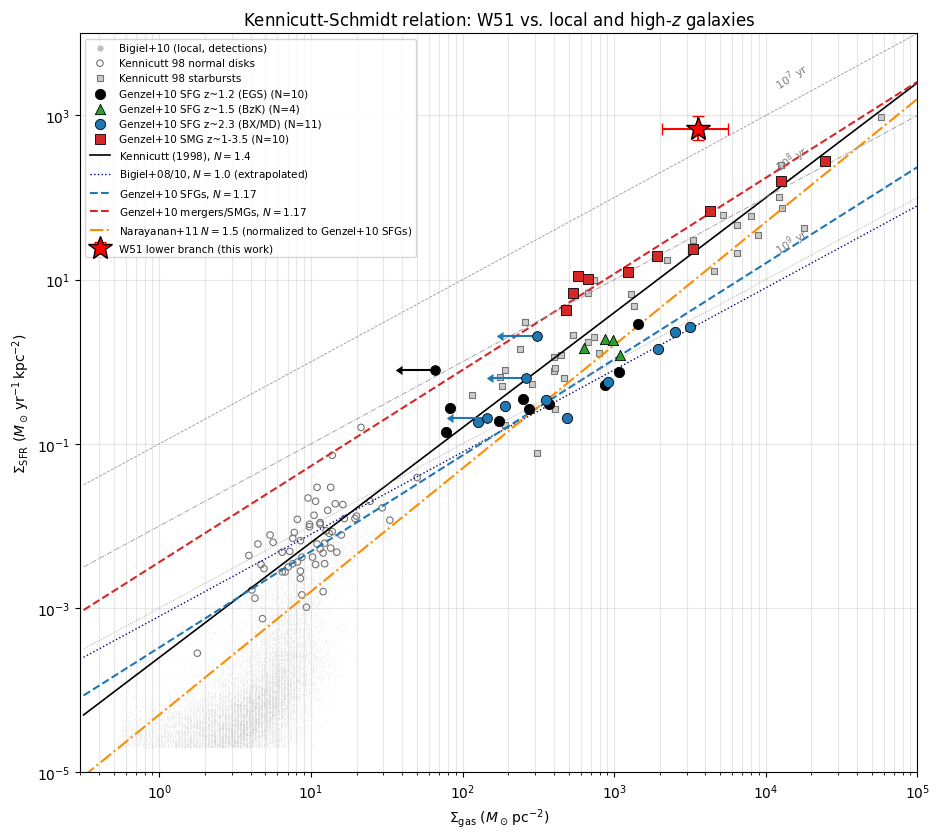

In [17]:
g10 = Table.read('genzel10_table1.csv', format='ascii.csv', comment='#')
g10_smg = np.array([s.startswith('SMG') for s in g10['sample']])
g10_ul = g10['co_upper_limit'] == 1


def ks_genzel10_sfg(sigma_gas):
    return 10**(1.17 * np.log10(sigma_gas) - 3.48)


def ks_genzel10_merger(sigma_gas):
    return 10**(1.17 * np.log10(sigma_gas) - 2.44)


# Narayanan+11 N = 1.5, intercept fitted to the Genzel+10 high-z SFG detections (fixed slope)
sfg_det = ~g10_smg & ~g10_ul
n11_intercept = np.mean(g10['log_sigma_SFR'][sfg_det] - 1.5 * g10['log_sigma_molgas'][sfg_det])


def ks_narayanan11(sigma_gas):
    return 10**(1.5 * np.log10(sigma_gas) + n11_intercept)


print(f'Genzel+10: {(~g10_smg).sum()} SFGs ({g10_ul.sum()} CO upper limits), {g10_smg.sum()} SMGs')
print(f'Narayanan+11 N=1.5 line normalized to Genzel SFGs: log Sigma_SFR = 1.5 log Sigma_gas {n11_intercept:+.2f}')
print(f'\nat the W51 Sigma_gas = {sg:.0f} Msun/pc^2 (observed Sigma_SFR = {ss:.0f}):')
for name, fn_ks in [('Kennicutt98', ks_kennicutt98), ('Bigiel08/10', ks_bigiel),
                    ('Genzel10 SFGs', ks_genzel10_sfg), ('Genzel10 mergers/SMGs', ks_genzel10_merger),
                    ('Narayanan11 N=1.5', ks_narayanan11)]:
    print(f'  {name:22s} predicts {fn_ks(sg):8.2f} Msun/yr/kpc^2 -> observed / predicted = {ss / fn_ks(sg):6.1f}')
tdep_g10 = 10**g10['log_sigma_molgas'] / 10**g10['log_sigma_SFR'] * 1e6 / 1e9  # Gyr
print(f'\ngas depletion times: W51 {(m_gas_unmasked / sfr).to_value(u.Gyr) * 1e3:.0f} Myr; '
      f'Genzel SFGs median {np.median(tdep_g10[sfg_det]) * 1e3:.0f} Myr, '
      f'SMGs median {np.median(tdep_g10[g10_smg]) * 1e3:.0f} Myr '
      f'(min {tdep_g10[g10_smg].min() * 1e3:.0f} Myr)')

fig, ax = plt.subplots(figsize=(9.5, 8.5))
xg = np.logspace(-0.5, 5, 200)
# local data, de-emphasized
ax.scatter(np.r_[b10_outer_gas[b10_outer_det], b10_inner_gas[b10_inner_det]],
           np.r_[b10_outer_sfr[b10_outer_det], b10_inner_sfr[b10_inner_det]],
           s=1, color='0.8', alpha=0.15, rasterized=True, lw=0)
ax.scatter([], [], s=12, color='0.75', label='Bigiel+10 (local, detections)')
ax.scatter(10**k98['log_sigma_gas'][k98_disk], 10**k98['log_sigma_SFR'][k98_disk], s=22, facecolor='none',
           edgecolor='0.45', lw=0.8, label='Kennicutt 98 normal disks')
ax.scatter(10**k98['log_sigma_gas'][~k98_disk], 10**k98['log_sigma_SFR'][~k98_disk], s=22, marker='s',
           facecolor='0.8', edgecolor='0.45', lw=0.8, label='Kennicutt 98 starbursts')

# Genzel+10 high-z galaxies
for samp, mk, col in [('SFG z~1.2 (EGS)', 'o', 'k'), ('SFG z~1.5 (BzK)', '^', 'tab:green'),
                      ('SFG z~2.3 (BX/MD)', 'o', 'tab:blue'), ('SMG z~1-3.5', 's', 'tab:red')]:
    sel = (g10['sample'] == samp)
    det, ul = sel & ~g10_ul, sel & g10_ul
    ax.scatter(10**g10['log_sigma_molgas'][det], 10**g10['log_sigma_SFR'][det], s=55, marker=mk, color=col,
               edgecolor='k', lw=0.6, zorder=5, label=f'Genzel+10 {samp} (N={sel.sum()})')
    if ul.any():
        ax.errorbar(10**g10['log_sigma_molgas'][ul], 10**g10['log_sigma_SFR'][ul],
                    xerr=0.4 * 10**g10['log_sigma_molgas'][ul], xuplims=True, fmt=mk, ms=7, color=col,
                    mec='k', mew=0.6, zorder=5)

ax.plot(xg, ks_kennicutt98(xg), 'k-', lw=1.2, label='Kennicutt (1998), $N=1.4$')
ax.plot(xg, ks_bigiel(xg), color='navy', lw=1, ls=':', label='Bigiel+08/10, $N=1.0$ (extrapolated)')
ax.plot(xg, ks_genzel10_sfg(xg), color='tab:blue', lw=1.5, ls='--', label='Genzel+10 SFGs, $N=1.17$')
ax.plot(xg, ks_genzel10_merger(xg), color='tab:red', lw=1.5, ls='--', label='Genzel+10 mergers/SMGs, $N=1.17$')
ax.plot(xg, ks_narayanan11(xg), color='darkorange', lw=1.5, ls='-.',
        label='Narayanan+11 $N=1.5$ (normalized to Genzel+10 SFGs)')
for tdep, ls in [(1e7, '--'), (1e8, '-.'), (1e9, ':')]:
    ax.plot(xg, xg * 1e6 / tdep, color='0.6', lw=0.6, ls=ls)
    ax.text(1.5e4, 1.5e4 * 1e6 / tdep * 1.4, f'$10^{{{int(np.log10(tdep))}}}$ yr', color='0.5', fontsize=8,
            rotation=33, ha='center')

ax.errorbar(sg, ss, xerr=[[sg - sigma_gas_lo.value], [sigma_gas_hi.value - sg]],
            yerr=[[ss - sigma_sfr_lo.value], [sigma_sfr_hi.value - ss]],
            fmt='*', ms=18, color='red', mec='k', capsize=4, zorder=6, label='W51 lower branch (this work)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.3, 1e5)
ax.set_ylim(1e-5, 1e4)
ax.set_xlabel(r'$\Sigma_{\rm gas}$ ($M_\odot\,{\rm pc^{-2}}$)')
ax.set_ylabel(r'$\Sigma_{\rm SFR}$ ($M_\odot\,{\rm yr^{-1}\,kpc^{-2}}$)')
ax.set_title('Kennicutt-Schmidt relation: W51 vs. local and high-$z$ galaxies')
ax.legend(fontsize=7.5, loc='upper left', ncol=1)
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('lower_branch_kennicutt_schmidt_highz.png', bbox_inches='tight')
plt.show()

### Result: W51 vs. high-redshift galaxies

| relation | predicted $\Sigma_{\rm SFR}$ at $\Sigma_{\rm gas}=3.6\times10^3\,M_\odot\,{\rm pc^{-2}}$ | W51 / predicted |
|---|---|---|
| Kennicutt (1998) | 24 | 29 |
| Bigiel et al. (2008, 2010), extrapolated | 2.9 | 240 |
| Genzel et al. (2010) SFGs | 4.8 | 140 |
| Genzel et al. (2010) mergers/SMGs | 52 | 13 |
| Narayanan et al. (2011) $N=1.5$ (normalized to Genzel SFGs) | 11 | 63 |

($\Sigma_{\rm SFR}$ in $M_\odot\,{\rm yr^{-1}\,kpc^{-2}}$.) The $z\sim1$-3.5 SMGs reach the same $\Sigma_{\rm gas}$ as W51 ($\sim10^3$-$10^4\,M_\odot\,{\rm pc^{-2}}$) but at $\Sigma_{\rm SFR}\sim20$-$300$, so W51 lies about an order of magnitude above even the merger/starburst sequence. Its gas depletion time ($\approx5$ Myr) is $\sim10\times$ shorter than the shortest Genzel SMG ($\approx50$ Myr; median 84 Myr) and $\sim200\times$ shorter than the high-$z$ SFG median ($\approx0.9$ Gyr).

The comparison mixes very different averaging scales and gas tracers: the high-$z$ points are averages within half-light radii of a few kpc, using CO with an assumed $\alpha_{\rm CO}$ (3.2 for SFGs, 1 for SMGs; adopting 3.2 for SMGs would move them 0.5 dex to higher $\Sigma_{\rm gas}$ and increase W51's offset from them), while W51 is a dust-based average over 32 pc$^2$ of a single protocluster region. The offset is therefore expected: galaxy-averaged surface densities include gas that is not forming stars and regions at different evolutionary stages, whereas the W51 measurement isolates one of the most actively star-forming clumps in the Galaxy.